# Sunoco Project - Machine Learning

In [135]:
# pip install --upgrade xgboost

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [137]:
# Loading dataset
Sunoco = pd.read_csv('Sunoco_Mastersheet.csv')

Sunoco['Week'] = pd.to_datetime(Sunoco['Week'])
Sunoco = Sunoco.sort_values('Week')
Sunoco.info()
Sunoco.head()

<class 'pandas.core.frame.DataFrame'>
Index: 534 entries, 533 to 0
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Week                           534 non-null    datetime64[ns]
 1   Gasoline_Stocks (thousands)    534 non-null    int64         
 2   Crude_Oil_Imports (thousands)  534 non-null    int64         
 3   Weather_HDD                    534 non-null    int64         
 4   Weather_CDD                    534 non-null    int64         
 5   Average_VMT                    534 non-null    int64         
 6   Financial_Stress_Index         534 non-null    float64       
 7   Gasoline_Prices                534 non-null    float64       
 8   Highway_Traffic                534 non-null    int64         
 9   US_GDP                         534 non-null    float64       
 10  Weekly_Jobless_Claims          534 non-null    int64         
 11  Rig_Count               

,Week,Gasoline_Stocks (thousands),Crude_Oil_Imports (thousands),Weather_HDD,Weather_CDD,Average_VMT,Financial_Stress_Index,Gasoline_Prices,Highway_Traffic,US_GDP,...,Rig_Count,Automobile_Sales,PCE,Refinery_Util,Eur_Crude_Prices,Weekly_EIA_Implied_GD,GeoPolitical_Risk_Index,Economic_Index,Unemployment Rate,S_P_500
533,2015-01-02,30536,6856,892,9,233498,-0.1216,2.214,3031,18063.53,...,1651,16.910,12066.7,87.8,56.03,8809,75.89857,2.47,5.7,2044.8
532,2015-01-09,30096,7492,892,9,233498,0.1301,2.139,3031,18063.53,...,1651,16.910,12066.7,87.8,49.47,8875,78.50857,3.05,5.7,2019.4
531,2015-01-16,30471,7218,892,9,233498,0.1338,2.066,3031,18063.53,...,1651,16.910,12066.7,87.8,46.58,8851,130.25710,2.95,5.7,2051.8
530,2015-01-23,28730,7422,892,9,233498,-0.0307,2.044,3031,18063.53,...,1651,16.910,12066.7,87.8,46.44,9022,119.72570,2.46,5.7,1995.0
529,2015-01-30,29828,7387,869,7,217220,-0.0081,2.068,3034,18063.53,...,1348,16.891,12116.6,87.1,46.76,8442,116.78430,2.55,5.7,2055.5


# Target Variable: Implied Gasoline Demand Binary Classification

In [140]:
Sunoco.reset_index(drop=True, inplace=True)
Sunoco = Sunoco.loc[:533]

In [142]:
Sunoco['Year'] = Sunoco['Week'].dt.year # Create new column for Year
# yearly_90th = Sunoco.groupby('Year')['Weekly_EIA_Implied_GD'].transform(lambda x: x.quantile(0.90)) # By year, compute 90th percentile
# Sunoco['High_Demand'] = np.where(Sunoco['Weekly_EIA_Implied_GD'] >= yearly_90th, 1, 0) # Assign binary targets, 1 = high demand, 0 = low demand
threshold_2024 = Sunoco.loc[Sunoco['Year'] == 2024, 'Weekly_EIA_Implied_GD'].quantile(0.70)
print("2024 70th Percentile Threshold:", threshold_2024)
Sunoco['High_Demand'] = np.where(Sunoco['Weekly_EIA_Implied_GD'] >= threshold_2024, 1, 0) # Assign binary targets, 1 = high demand, 0 = low demand

2024 70th Percentile Threshold: 9042.8


In [144]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X = Sunoco.drop(columns=['Weekly_EIA_Implied_GD','High_Demand']) # Set predictors
y = Sunoco['High_Demand'] # Set target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.11,
    random_state = 42,
    shuffle = False)

print(f"Training size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(X_test.head(1))
print(X_train.isna().sum())
print(X_test.isna().sum())
print(X_train.shape)
print(X_test.shape)

Training size: 475, Test size: 59
          Week  Gasoline_Stocks (thousands)  Crude_Oil_Imports (thousands)  \
475 2024-02-09                        15810                           6470   

     Weather_HDD  Weather_CDD  Average_VMT  Financial_Stress_Index  \
475          575           13       241014                 -0.5953   

     Gasoline_Prices  Highway_Traffic    US_GDP  ...  Rig_Count  \
475            3.192             3250  28708.16  ...        622   

     Automobile_Sales      PCE  Refinery_Util  Eur_Crude_Prices  \
475            16.262  19446.5           82.7             81.51   

     GeoPolitical_Risk_Index  Economic_Index  Unemployment Rate  S_P_500  Year  
475                 119.7486            1.52                3.9  5005.57  2024  

[1 rows x 21 columns]
Week                             0
Gasoline_Stocks (thousands)      0
Crude_Oil_Imports (thousands)    0
Weather_HDD                      0
Weather_CDD                      0
Average_VMT                      0
Fin

# Cleaning Both Train and Test + Time-Lag

# Rig Count

Train:
min        250.000000
max       1651.000000
median     758.000000
mean       737.366316
std        248.679196
Name: Rig_Count, dtype: float64


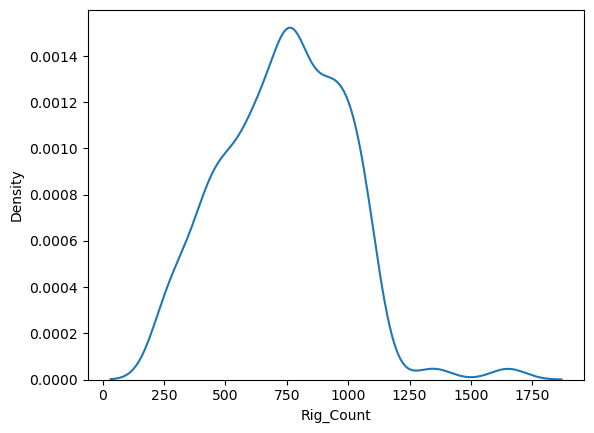

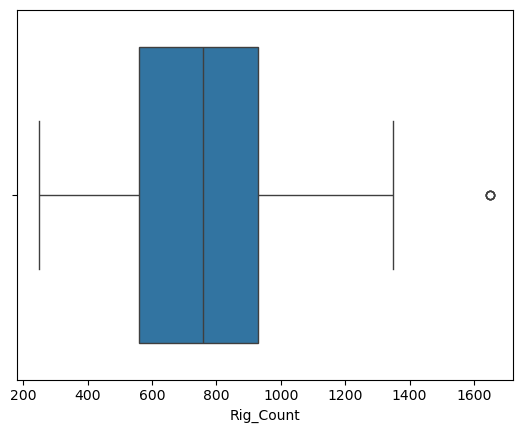

0


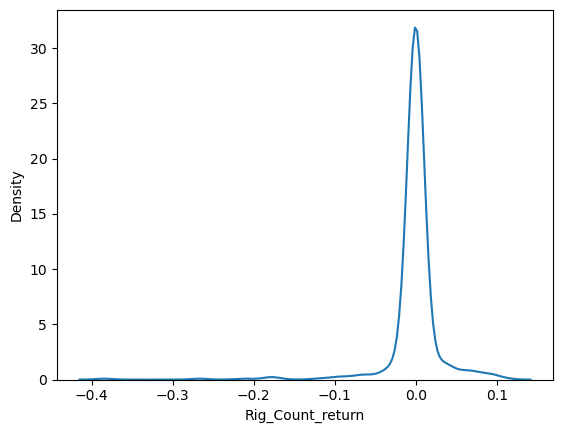

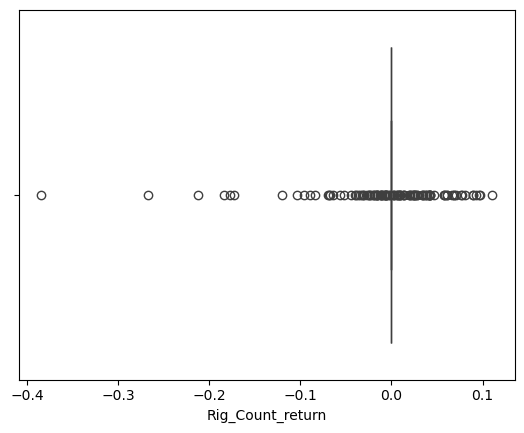

Test:
min       582.000000
max       625.000000
median    588.000000
mean      595.033898
std        14.328614
Name: Rig_Count, dtype: float64


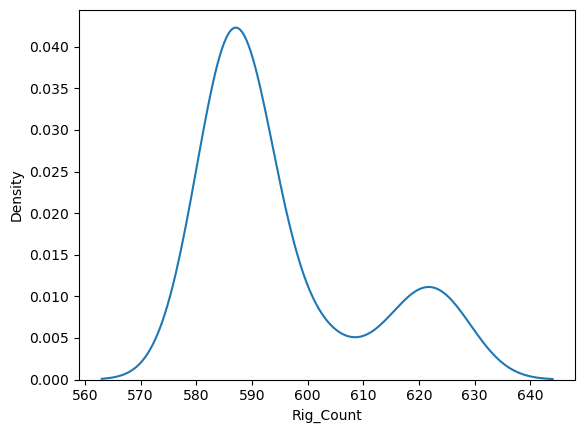

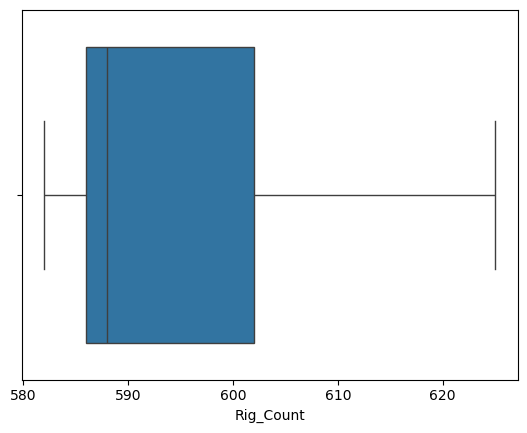

0


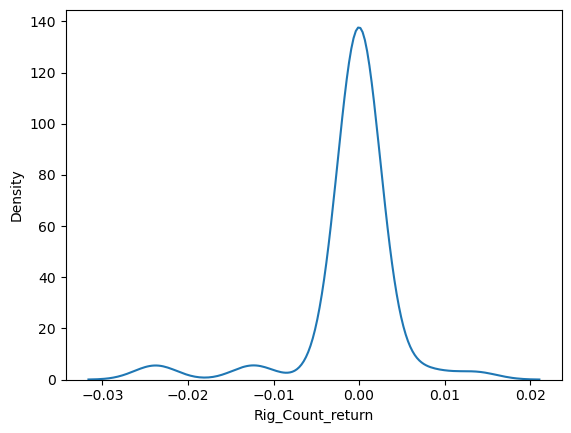

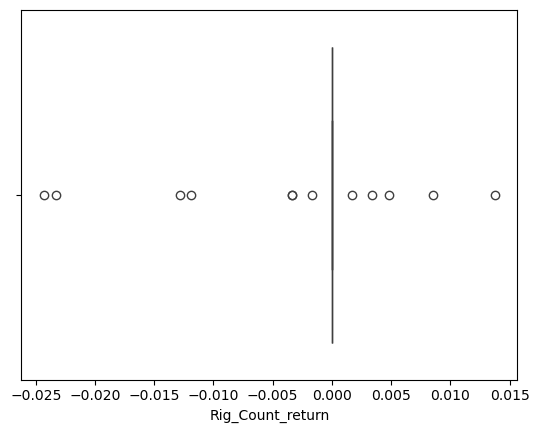

In [148]:
# Train
print("Train:")
print(X_train.Rig_Count.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Rig_Count) # kdeplot to see distribution
plt.show()
sns.boxplot(x = X_train.Rig_Count) # boxplot to see distribution
plt.show()
print(X_train.Rig_Count.isna().sum()) # Check Missing values

X_train["Rig_Count_return"] = X_train["Rig_Count"].pct_change() # New variable to capture sudden spikes
sns.kdeplot(x = X_train.Rig_Count_return) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_train.Rig_Count_return) # boxplot to see distribution. 
plt.show()

X_train = X_train.drop(columns=['Rig_Count']) # Drop original

# Test
print("Test:")
print(X_test.Rig_Count.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Rig_Count) # kdeplot to see distribution
plt.show()
sns.boxplot(x = X_test.Rig_Count) # boxplot to see distribution
plt.show()
print(X_test.Rig_Count.isna().sum()) # Check Missing values

X_test["Rig_Count_return"] = X_test["Rig_Count"].pct_change() # Create same new variable for test
sns.kdeplot(x = X_test.Rig_Count_return) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_test.Rig_Count_return) # boxplot to see distribution. 
plt.show()

X_test = X_test.drop(columns=['Rig_Count']) # Drop original

## Rig Count Time-Lag

In [150]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Rig_Count_return_lag{L}"] = X_train["Rig_Count_return"].shift(L) # Apply to train
    X_test[f"Rig_Count_return_lag{L}"] = X_test["Rig_Count_return"].shift(L) # Apply to test

# Europe Spot Crude Prices

Train:
min        14.240000
max       127.400000
median     63.360000
mean       64.725558
std        19.826860
Name: Eur_Crude_Prices, dtype: float64


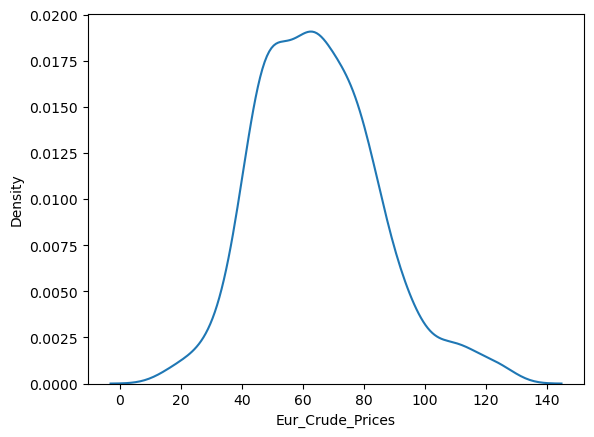

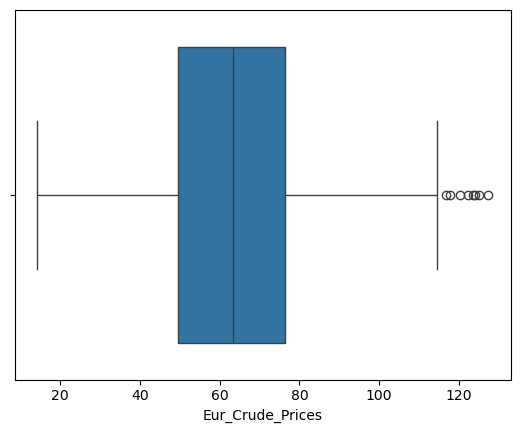

0
Test:
min       71.540000
max       92.010000
median    79.570000
mean      79.666780
std        5.523582
Name: Eur_Crude_Prices, dtype: float64


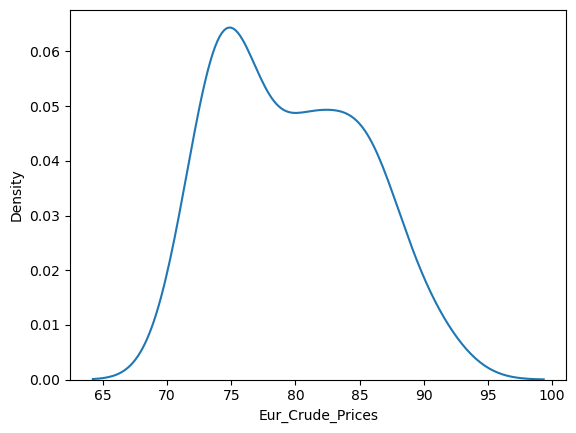

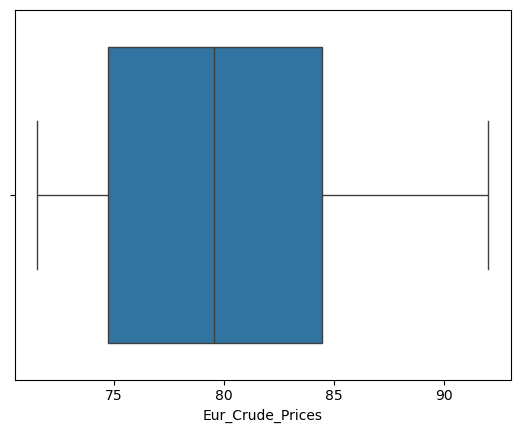

0


In [154]:
# Train
print("Train:")
print(X_train.Eur_Crude_Prices.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Eur_Crude_Prices) # kdeplot to see distribution
plt.show()
sns.boxplot(x = X_train.Eur_Crude_Prices) # boxplot to see distribution. There are some outliers, but these represent real shocks. It's a signal, not noise
plt.show()
print(X_train.Eur_Crude_Prices.isna().sum()) # Check Missing values
# Keep as is

# Test
print("Test:")
print(X_test.Eur_Crude_Prices.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Eur_Crude_Prices) # kdeplot to see distribution
plt.show()
sns.boxplot(x = X_test.Eur_Crude_Prices) # boxplot to see distribution. 
plt.show()
print(X_test.Eur_Crude_Prices.isna().sum()) # Check Missing values
# Leave as is as done for train

## Europe Spot Crude Prices Time-Lag

In [157]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Eur_Crude_Prices_lag{L}"] = X_train["Eur_Crude_Prices"].shift(L) # Apply to train
    X_test[f"Eur_Crude_Prices_lag{L}"] = X_test["Eur_Crude_Prices"].shift(L) # Apply to test

# Refinery Utilization

Train:
min       70.200000
max       97.000000
median    90.300000
mean      89.164421
std        5.325306
Name: Refinery_Util, dtype: float64


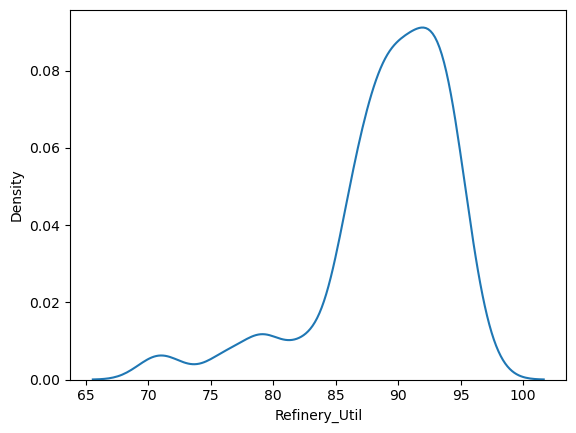

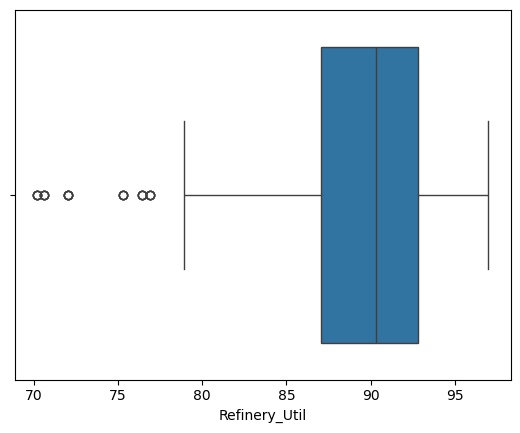

0


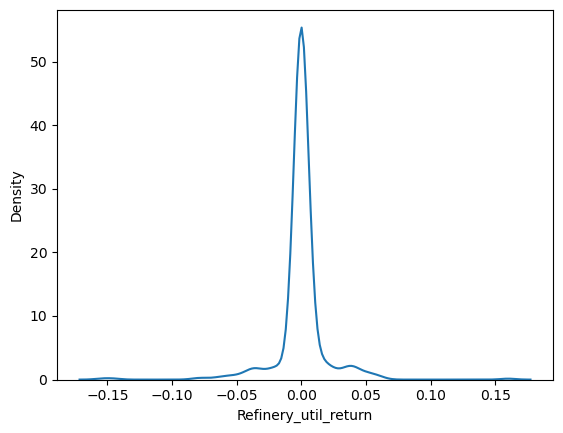

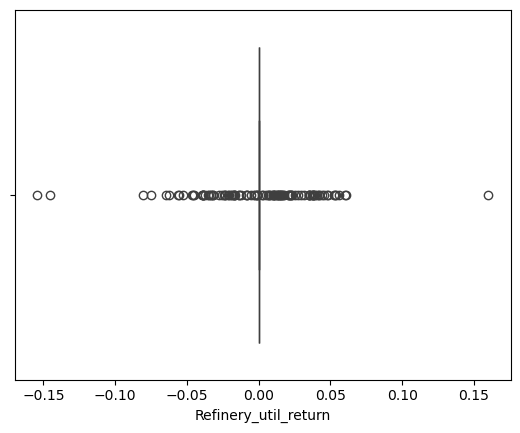

Test:
min       82.700000
max       94.200000
median    90.400000
mean      90.264407
std        3.195674
Name: Refinery_Util, dtype: float64


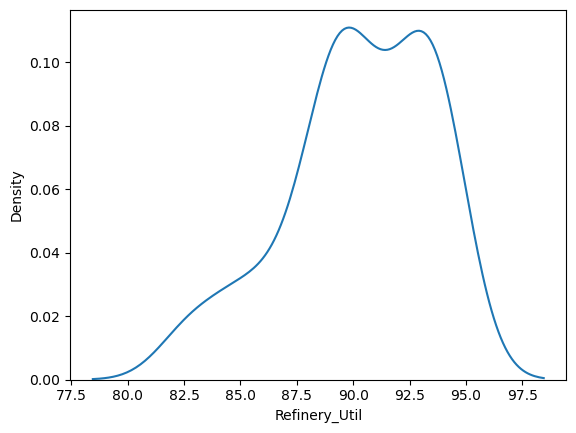

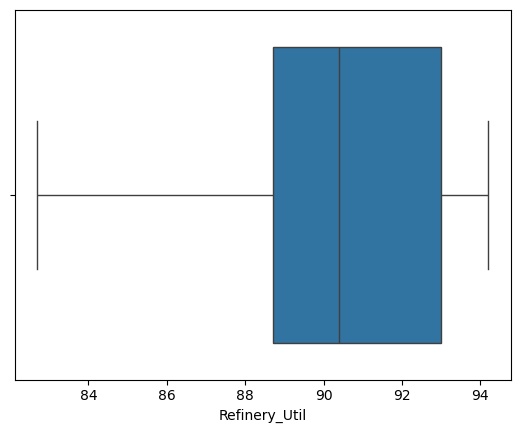

0


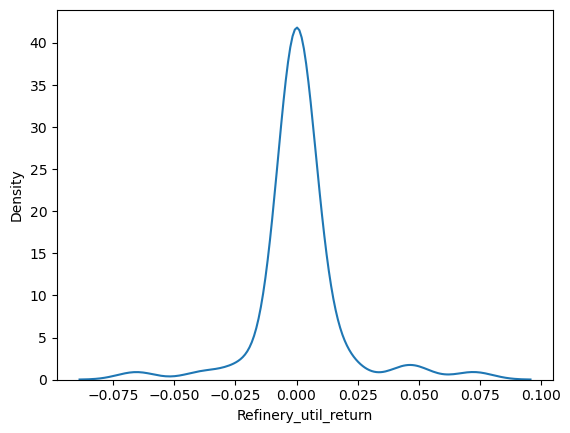

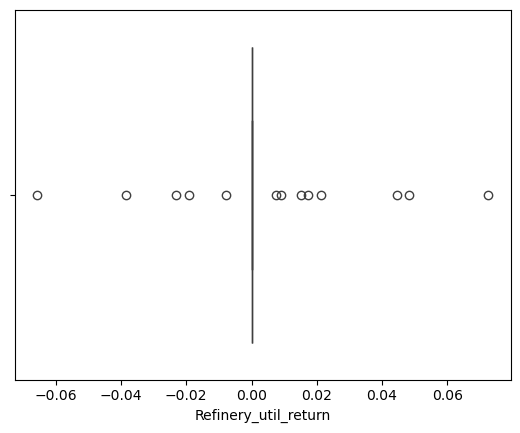

In [160]:
# Train
print("Train:")
print(X_train.Refinery_Util.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Refinery_Util) # kdeplot to see distribution. Heavily left skewed, but the skew is meaningful. These low values are real market shocks.
plt.show() # The skew is very informative for classification models
sns.boxplot(x = X_train.Refinery_Util) # boxplot to see distribution. 
plt.show()
print(X_train.Refinery_Util.isna().sum()) # Check Missing values

X_train["Refinery_util_return"] = X_train["Refinery_Util"].pct_change() # New variable to capture sudden drops
sns.kdeplot(x = X_train.Refinery_util_return) # kdeplot to see distribution. Helps see sudden spikes
plt.show() 
sns.boxplot(x = X_train.Refinery_util_return) # boxplot to see distribution. 
plt.show()

X_train = X_train.drop(columns=['Refinery_Util']) # Drop original

# Test
print("Test:")
print(X_test.Refinery_Util.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Refinery_Util) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_test.Refinery_Util) # boxplot to see distribution. 
plt.show()
print(X_test.Refinery_Util.isna().sum()) # Check Missing values

X_test["Refinery_util_return"] = X_test["Refinery_Util"].pct_change() # Create same new variable for test
sns.kdeplot(x = X_test.Refinery_util_return) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_test.Refinery_util_return) # boxplot to see distribution. 
plt.show()

X_test = X_test.drop(columns=['Refinery_Util']) # Drop original

## Refinery Utilization Time-Lag

In [162]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Refinery_util_return_lag{L}"] = X_train["Refinery_util_return"].shift(L) # Apply to train
    X_test[f"Refinery_util_return_lag{L}"] = X_test["Refinery_util_return"].shift(L) # Apply to test

# Temperature HDD

Train:
min         4.000000
max       914.000000
median    257.000000
mean      340.204211
std       299.623242
Name: Weather_HDD, dtype: float64


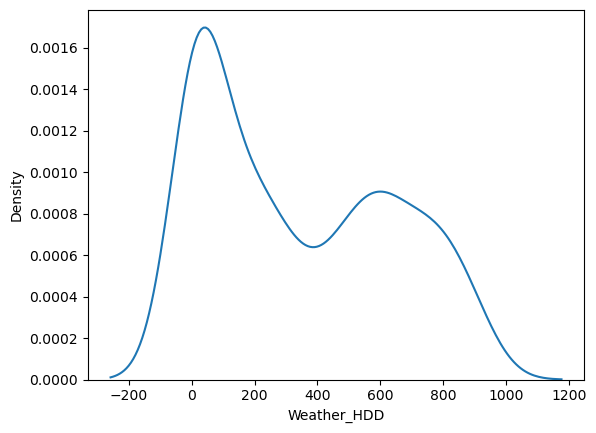

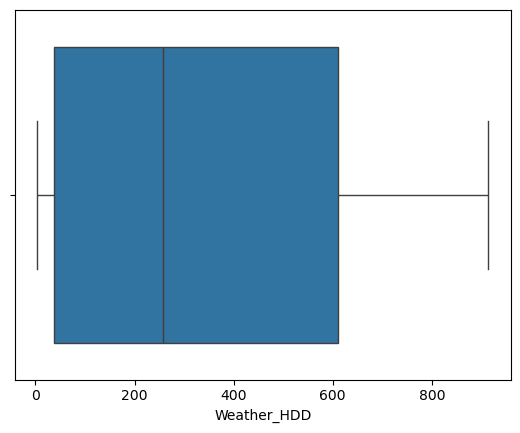

0
Test:
min         4.000000
max       946.000000
median    281.000000
mean      347.033898
std       298.265848
Name: Weather_HDD, dtype: float64


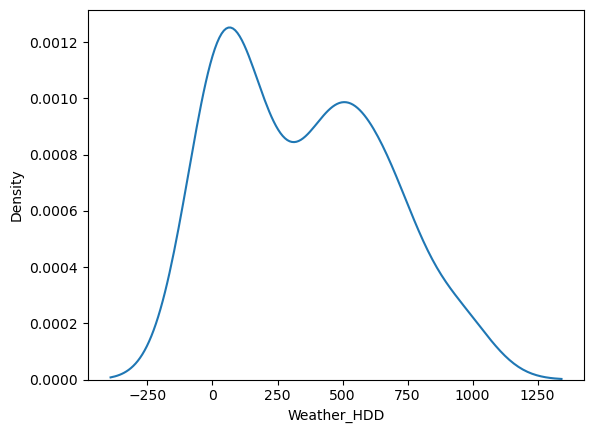

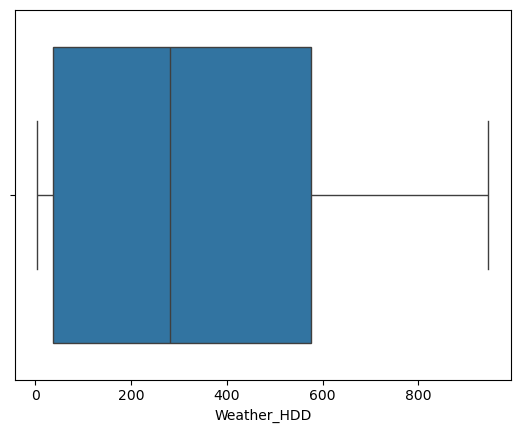

0


In [166]:
# Train
print("Train:")
print(X_train.Weather_HDD.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Weather_HDD) # kdeplot to see distribution. Slight right-skew, but shape is to be expected. One peak for summer, and one peak for winter.
plt.show() # The skew is very informative for classification models
sns.boxplot(x = X_train.Weather_HDD) # boxplot to see distribution. 
plt.show()
print(X_train.Weather_HDD.isna().sum()) # Check Missing values
# Keep as is

# Test
print("Test:")
print(X_test.Weather_HDD.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Weather_HDD) # kdeplot to see distribution. 
plt.show() # The skew is very informative for classification models
sns.boxplot(x = X_test.Weather_HDD) # boxplot to see distribution. 
plt.show()
print(X_test.Weather_HDD.isna().sum()) # Check Missing values
# Keep as is as done for train

## Temperature HDD Time-Lag

In [169]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Weather_HDD_lag{L}"] = X_train["Weather_HDD"].shift(L) # Apply to train
    X_test[f"Weather_HDD_lag{L}"] = X_test["Weather_HDD"].shift(L) # Apply to test

# Temperature CDD

Train:
min         7.000000
max       398.000000
median     55.000000
mean      124.934737
std       129.693073
Name: Weather_CDD, dtype: float64


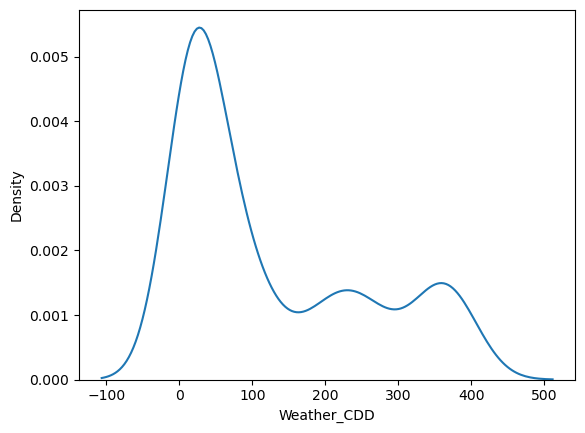

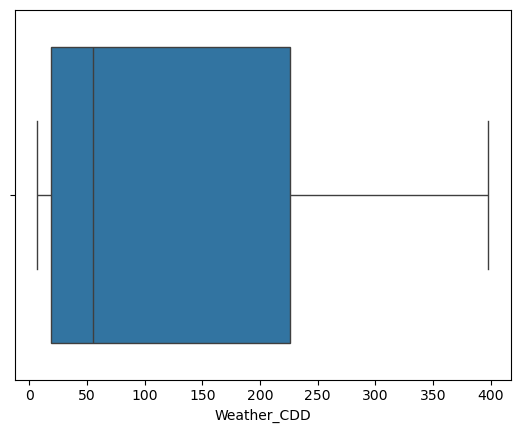

0
Test:
min         5.000000
max       390.000000
median     47.000000
mean      122.983051
std       131.074931
Name: Weather_CDD, dtype: float64


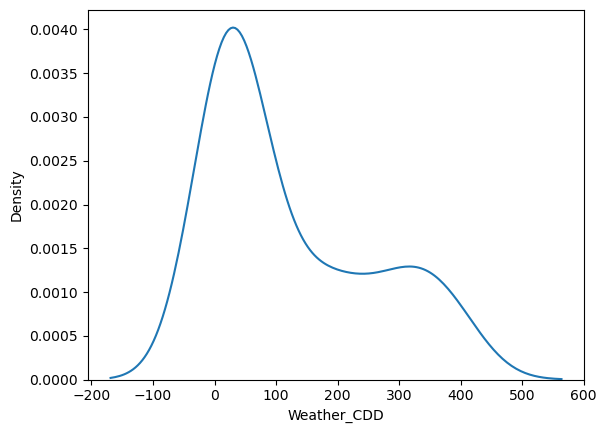

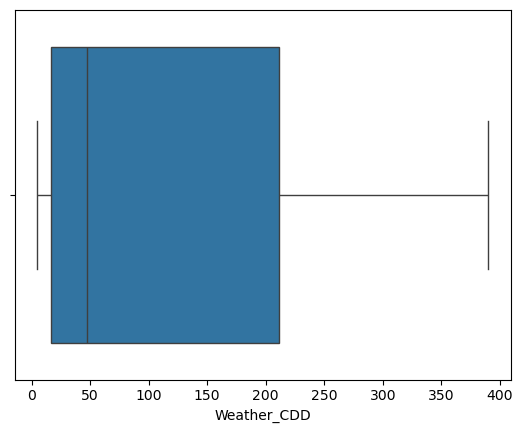

0


In [172]:
# Train
print("Train:")
print(X_train.Weather_CDD.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Weather_CDD) # kdeplot to see distribution. Right-skewed, but shape is expected. One main peak for winter and another small peak for summer.
plt.show() # The skew is very informative for classification models
sns.boxplot(x = X_train.Weather_CDD) # boxplot to see distribution. 
plt.show()
print(X_train.Weather_CDD.isna().sum()) # Check Missing values
# Keep as is

# Test
print("Test:")
print(X_test.Weather_CDD.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Weather_CDD) # kdeplot to see distribution. 
plt.show() # The skew is very informative for classification models
sns.boxplot(x = X_test.Weather_CDD) # boxplot to see distribution. 
plt.show()
print(X_test.Weather_CDD.isna().sum()) # Check Missing values
# Keep as is as done for train

## Temperature CDD Time-Lag

In [174]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Weather_CDD_lag{L}"] = X_train["Weather_CDD"].shift(L) # Apply to train
    X_test[f"Weather_CDD_lag{L}"] = X_test["Weather_CDD"].shift(L) # Apply to test

# Weekly Jobless Claims

Train:
min       1.890000e+05
max       6.137000e+06
median    2.380000e+05
mean      3.841516e+05
std       5.732458e+05
Name: Weekly_Jobless_Claims, dtype: float64


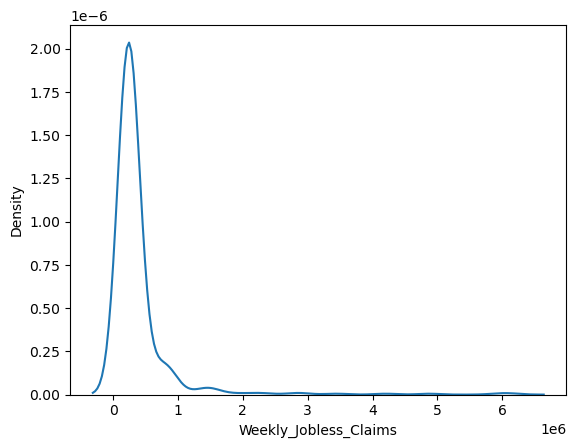

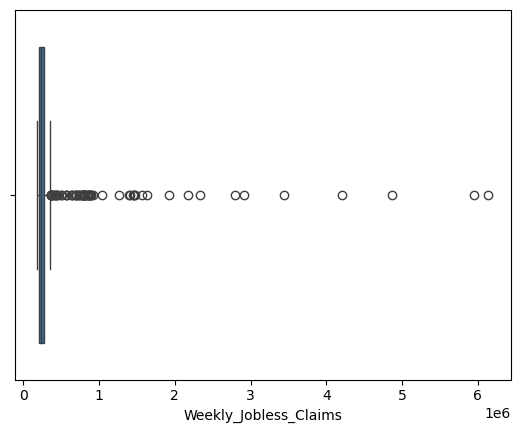

0


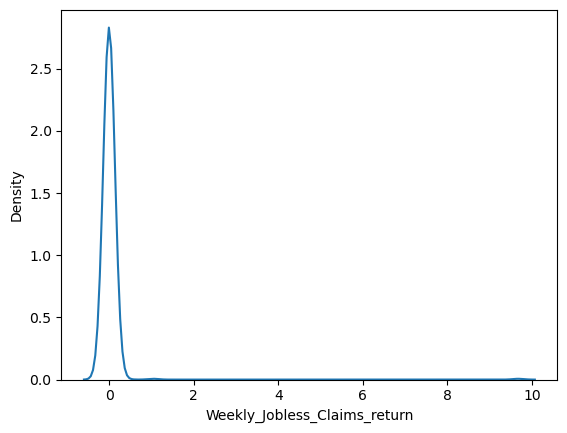

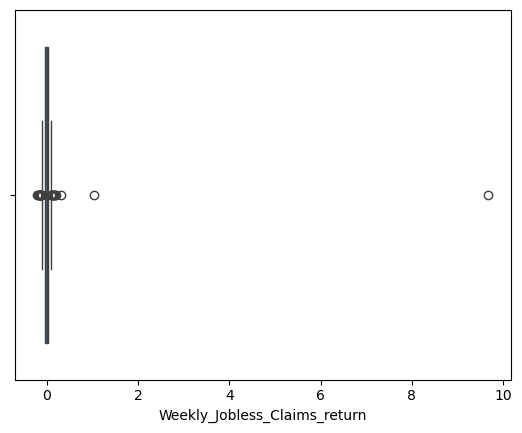

Test:
min       203000.000000
max       259000.000000
median    222000.000000
mean      223677.966102
std        11236.395112
Name: Weekly_Jobless_Claims, dtype: float64


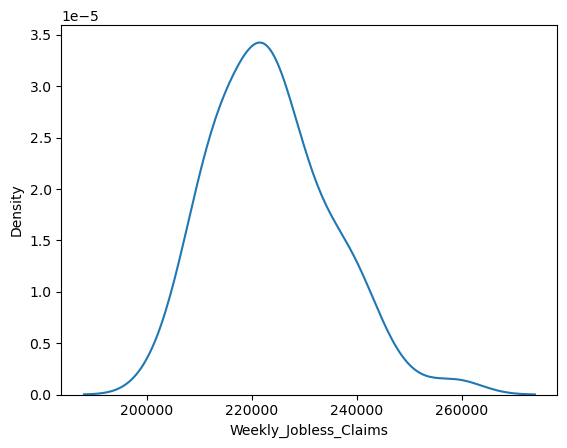

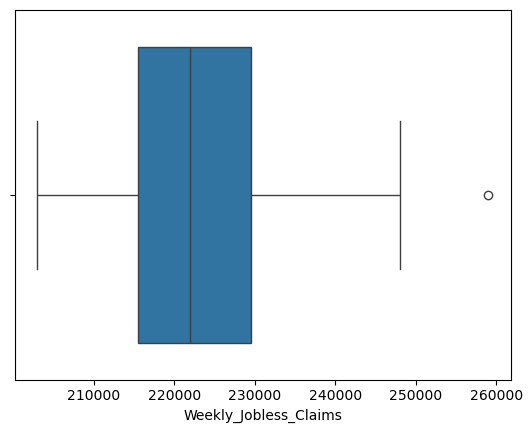

0


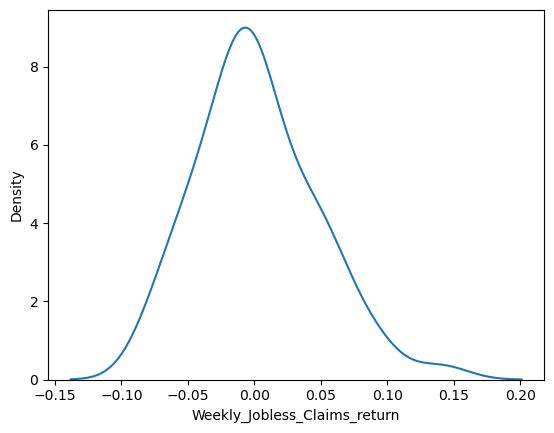

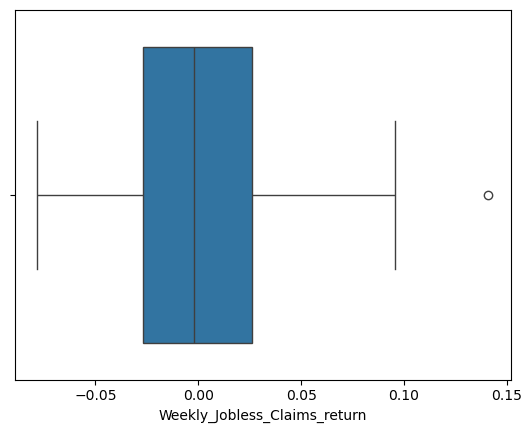

In [178]:
# Train
print("Train:")
print(X_train.Weekly_Jobless_Claims.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Weekly_Jobless_Claims) # kdeplot to see distribution. Extremely right-skewed. All real economic events, not noise.
plt.show() # The skew is very informative for classification models
sns.boxplot(x = X_train.Weekly_Jobless_Claims) # boxplot to see distribution. 
plt.show()
print(X_train.Weekly_Jobless_Claims.isna().sum()) # Check Missing values

X_train["Weekly_Jobless_Claims_return"] = X_train["Weekly_Jobless_Claims"].pct_change() # New variable to capture sudden spikes
sns.kdeplot(x = X_train.Weekly_Jobless_Claims_return) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_train.Weekly_Jobless_Claims_return) # boxplot to see distribution. 
plt.show()

X_train = X_train.drop(columns=['Weekly_Jobless_Claims']) # Drop original

# Test
print("Test:")
print(X_test.Weekly_Jobless_Claims.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Weekly_Jobless_Claims) # kdeplot to see distribution.
plt.show() # The skew is very informative for classification models
sns.boxplot(x = X_test.Weekly_Jobless_Claims) # boxplot to see distribution. 
plt.show()
print(X_test.Weekly_Jobless_Claims.isna().sum()) # Check Missing values

X_test["Weekly_Jobless_Claims_return"] = X_test["Weekly_Jobless_Claims"].pct_change() # Create same new variable for test
sns.kdeplot(x = X_test.Weekly_Jobless_Claims_return) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_test.Weekly_Jobless_Claims_return) # boxplot to see distribution. 
plt.show()

X_test = X_test.drop(columns=['Weekly_Jobless_Claims']) # Drop original

## Weekly Jobless Claims Time-Lag

In [180]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Weekly_Jobless_Claims_return_lag{L}"] = X_train["Weekly_Jobless_Claims_return"].shift(L) # Apply to train
    X_test[f"Weekly_Jobless_Claims_return_lag{L}"] = X_test["Weekly_Jobless_Claims_return"].shift(L) # Apply to test

# S&P 500

Train:
min       1864.800000
max       5026.610000
median    2905.030000
mean      3150.515432
std        889.041289
Name: S_P_500, dtype: float64
0.32250452839732485


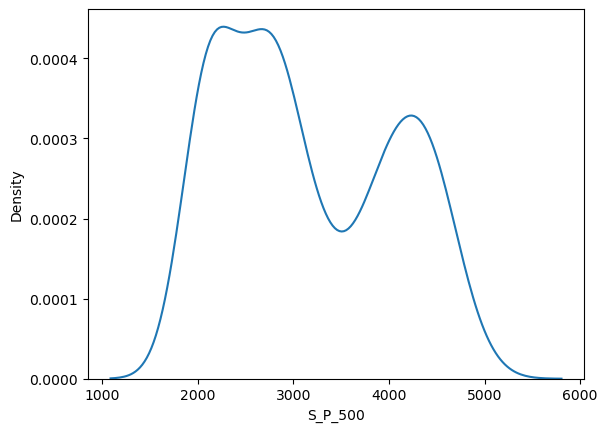

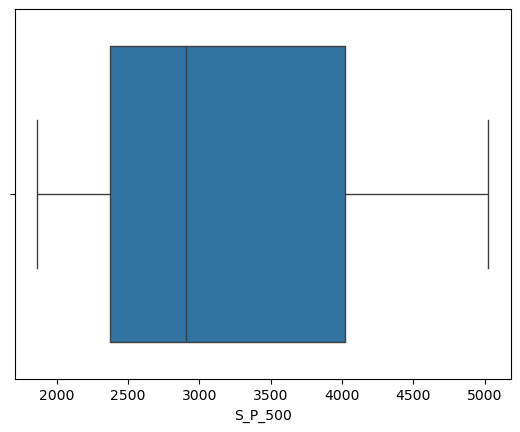

0
Test:
min       4967.230000
max       6114.630000
median    5626.020000
mean      5593.179492
std        336.652328
Name: S_P_500, dtype: float64
-0.12435250476619202


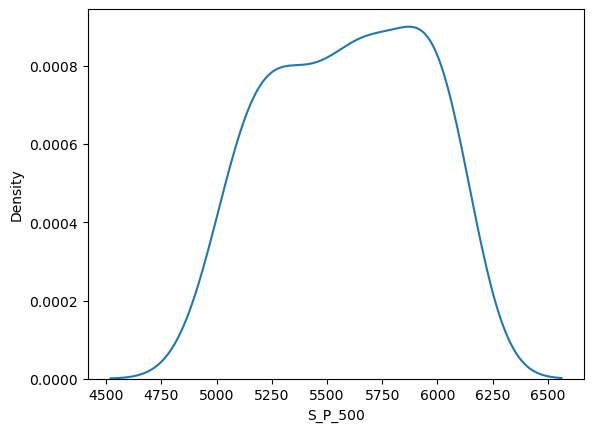

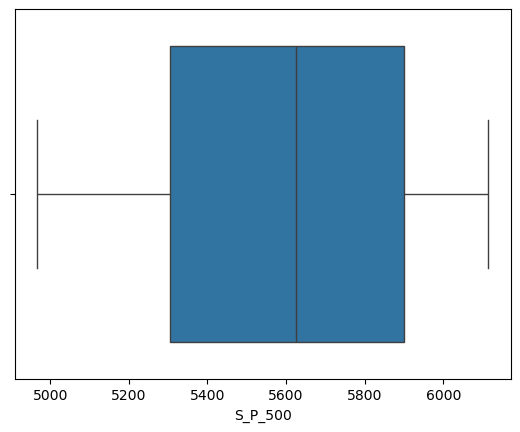

0


In [183]:
# Train
print("Train:")
print(X_train.S_P_500.agg(['min','max','median','mean','std'])) # descriptive stats
print(X_train['S_P_500'].skew()) # check skew
sns.kdeplot(x = X_train.S_P_500) # kdeplot to see distribution. All realistic values; the two peaks reflect real economic behaviors, not outliers or skew
plt.show() 
sns.boxplot(x = X_train.S_P_500) # boxplot to see distribution. 
plt.show()
print(X_train.S_P_500.isna().sum()) # Check Missing values
# Keep as is

# Test
print("Test:")
print(X_test.S_P_500.agg(['min','max','median','mean','std'])) # descriptive stats
print(X_test['S_P_500'].skew()) # Check skew
sns.kdeplot(x = X_test.S_P_500) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test.S_P_500) # boxplot to see distribution. 
plt.show()
print(X_test.S_P_500.isna().sum()) # Check Missing values
# Leave as is as done for train

## S&P 500 Time-Lag

In [186]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"S_P_500_lag{L}"] = X_train["S_P_500"].shift(L) # Apply to train
    X_test[f"S_P_500_lag{L}"] = X_test["S_P_500"].shift(L) # Apply to test

# Economic Index

Train:
min       -8.120000
max       10.560000
median     2.120000
mean       2.127074
std        2.589354
Name: Economic_Index, dtype: float64
-0.5227353205380221


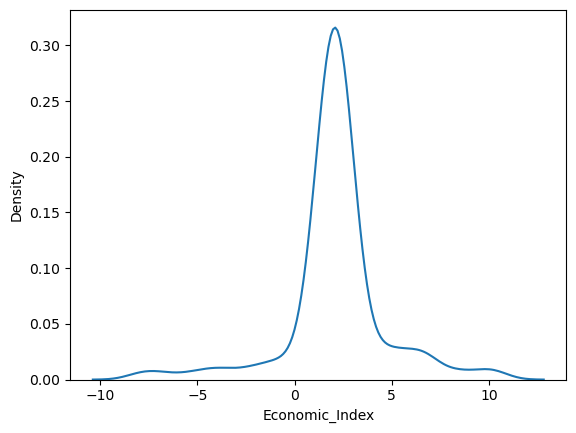

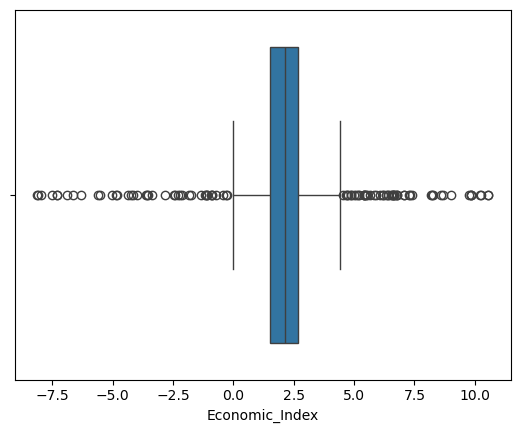

0
Test:
min       1.480000
max       3.210000
median    2.030000
mean      2.108644
std       0.369125
Name: Economic_Index, dtype: float64
0.6224903764233402


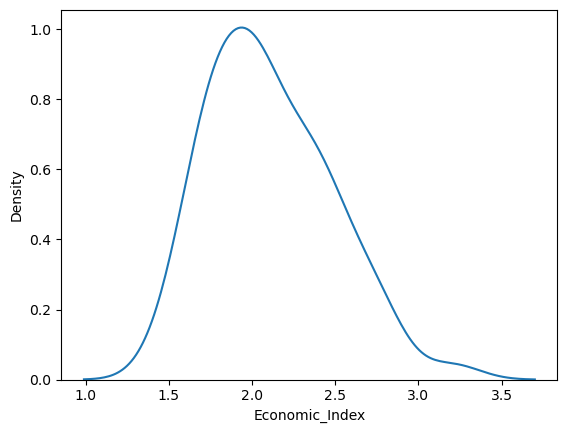

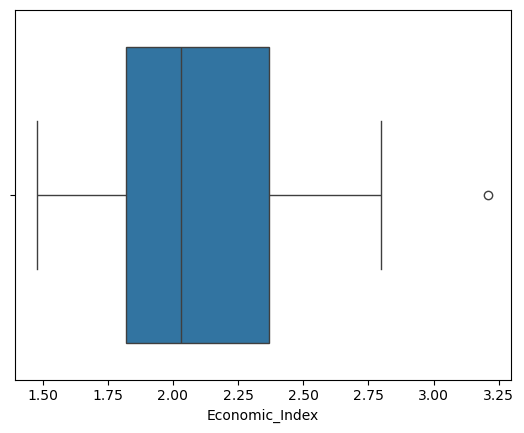

0


In [190]:
# Train
print("Train:")
print(X_train.Economic_Index.agg(['min','max','median','mean','std'])) # descriptive stats
print(X_train['Economic_Index'].skew()) # check skew. Small left skew
sns.kdeplot(x = X_train.Economic_Index) # kdeplot to see distribution. No unrealistic values, since negative values are valid (below-trend economic activity)
plt.show() 
sns.boxplot(x = X_train.Economic_Index) # boxplot to see distribution. Outliers are economically meaningful.
plt.show()
print(X_train.Economic_Index.isna().sum()) # Check Missing values
# Keep as is

# Test
print("Test:")
print(X_test.Economic_Index.agg(['min','max','median','mean','std'])) # descriptive stats
print(X_test['Economic_Index'].skew()) # Check skew
sns.kdeplot(x = X_test.Economic_Index) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test.Economic_Index) # boxplot to see distribution. 
plt.show()
print(X_test.Economic_Index.isna().sum()) # Check Missing values
# Leave as is as done for train

## Economic Index Time-Lag

In [193]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Economic_Index_lag{L}"] = X_train["Economic_Index"].shift(L) # Apply to train
    X_test[f"Economic_Index_lag{L}"] = X_test["Economic_Index"].shift(L) # Apply to test

# Unemployment Rate

Train:
min        3.400000
max       14.800000
median     4.200000
mean       4.749053
std        1.805060
Name: Unemployment Rate, dtype: float64
3.2725707372407027


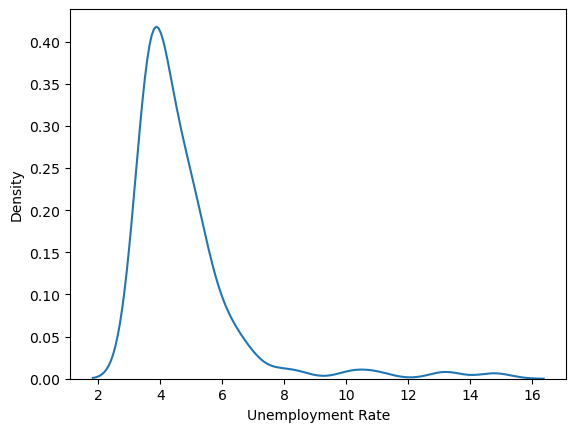

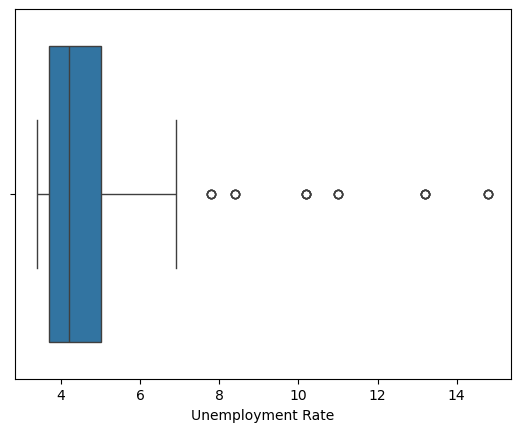

0
Test:
min       3.900000
max       4.200000
median    4.100000
mean      4.071186
std       0.109939
Name: Unemployment Rate, dtype: float64
-0.3625244980591356


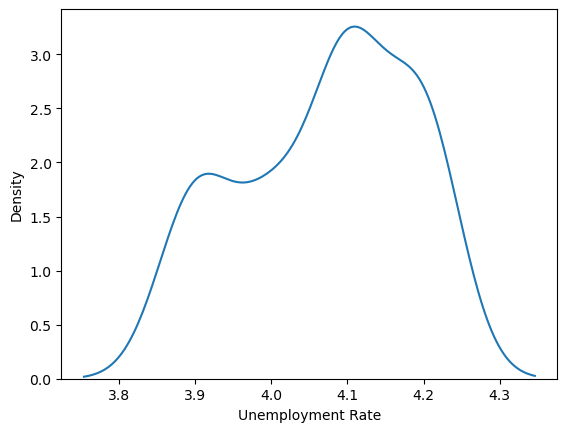

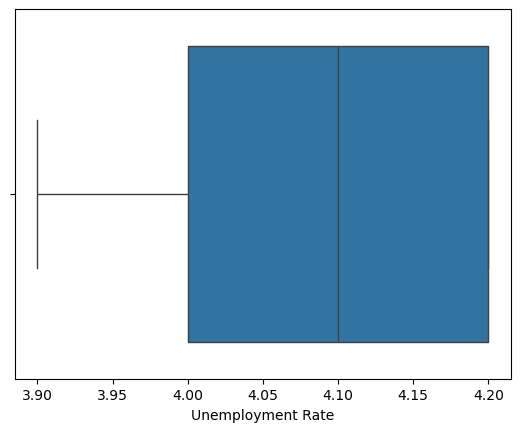

0


In [196]:
# Train
print("Train:")
print(X_train['Unemployment Rate'].agg(['min','max','median','mean','std'])) # descriptive stats
print(X_train['Unemployment Rate'].skew()) # check skew. Right-skewed, but to be expected
sns.kdeplot(x = X_train['Unemployment Rate']) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_train['Unemployment Rate']) # boxplot to see distribution. 
plt.show() # outliers represent periods of labor market distress. An important signal, and not noise.
print(X_train['Unemployment Rate'].isna().sum()) # Check Missing values
# Keep as is

# Test
print("Test:")
print(X_test['Unemployment Rate'].agg(['min','max','median','mean','std'])) # descriptive stats
print(X_test['Unemployment Rate'].skew()) # Check skew
sns.kdeplot(x = X_test['Unemployment Rate']) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test['Unemployment Rate']) # boxplot to see distribution. 
plt.show()
print(X_test['Unemployment Rate'].isna().sum()) # Check Missing values
# Leave as is as done for train

## Unemployment Rate Time-Lag

In [199]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Unemployment_Rate_lag{L}"] = X_train["Unemployment Rate"].shift(L) # Apply to train
    X_test[f"Unemployment_Rate_lag{L}"] = X_test["Unemployment Rate"].shift(L) # Apply to test

# Automobile Sales

Train:
min        8.919000
max       18.574000
median    17.130000
mean      16.552120
std        1.761618
Name: Automobile_Sales, dtype: float64
-1.435701394521118


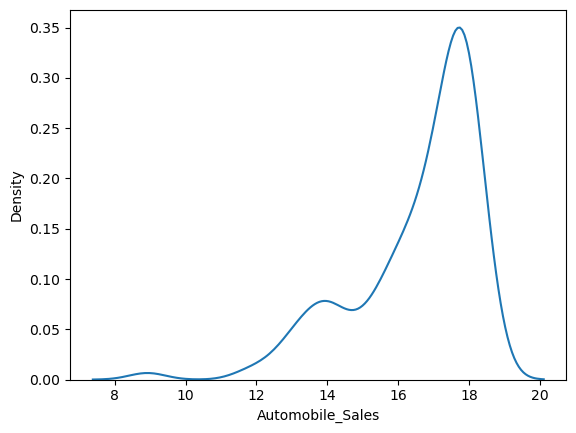

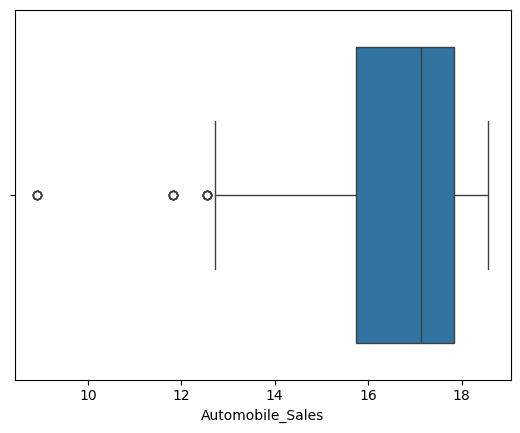

0
Test:
min       15.774000
max       18.331000
median    16.325000
mean      16.513220
std        0.638725
Name: Automobile_Sales, dtype: float64
1.5966041023330855


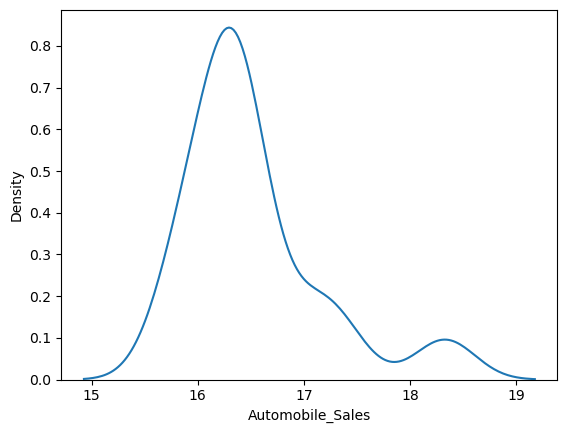

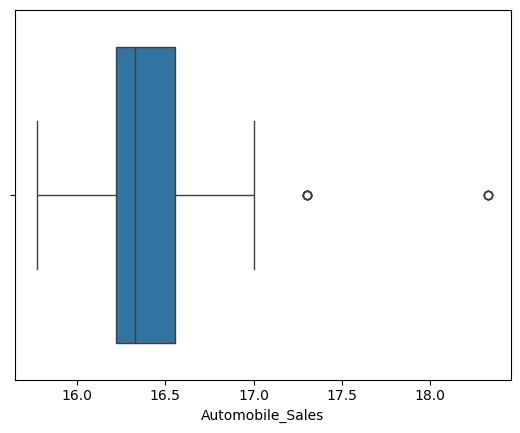

0


In [202]:
# Train
print("Train:")
print(X_train.Automobile_Sales.agg(['min','max','median','mean','std'])) # descriptive stats
print(X_train['Automobile_Sales'].skew()) # check skew. Left-skewed
sns.kdeplot(x = X_train.Automobile_Sales) # kdeplot to see distribution. There are two main peaks
plt.show() 
sns.boxplot(x = X_train.Automobile_Sales) # boxplot to see distribution.
plt.show() # outliers correspond to low periods where car sales were low, not necessarily data errors
print(X_train.Automobile_Sales.isna().sum()) # Check Missing values
# Keep as is for interpretability

# Test
print("Test:")
print(X_test.Automobile_Sales.agg(['min','max','median','mean','std'])) # descriptive stats
print(X_test['Automobile_Sales'].skew()) # Check skew. Small right-skew
sns.kdeplot(x = X_test.Automobile_Sales) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test.Automobile_Sales) # boxplot to see distribution. 
plt.show()
print(X_test.Automobile_Sales.isna().sum()) # Check Missing values
# Leave as is as done for train for interpretability

## Automobile Sales Time-Lag

In [205]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Automobile_Sales_lag{L}"] = X_train["Automobile_Sales"].shift(L) # Apply to train
    X_test[f"Automobile_Sales_lag{L}"] = X_test["Automobile_Sales"].shift(L) # Apply to test

# Gasoline Prices

Train:
min       1.724000
max       5.006000
median    2.611000
mean      2.776579
std       0.632604
Name: Gasoline_Prices, dtype: float64


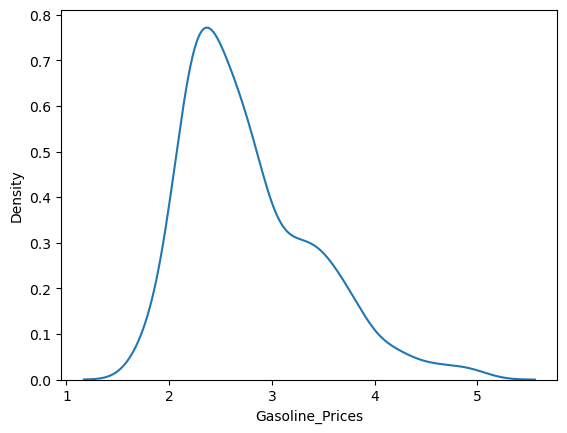

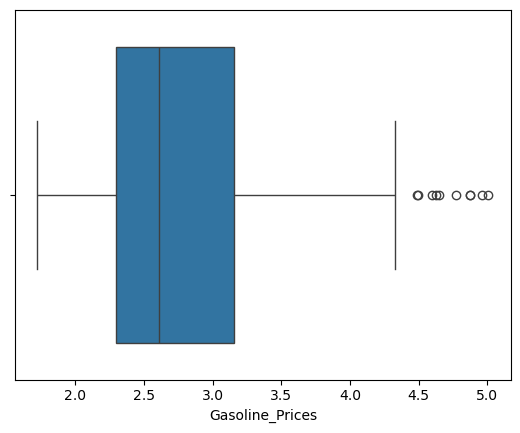

0
Test:
min       3.006000
max       3.668000
median    3.236000
mean      3.282983
std       0.211394
Name: Gasoline_Prices, dtype: float64


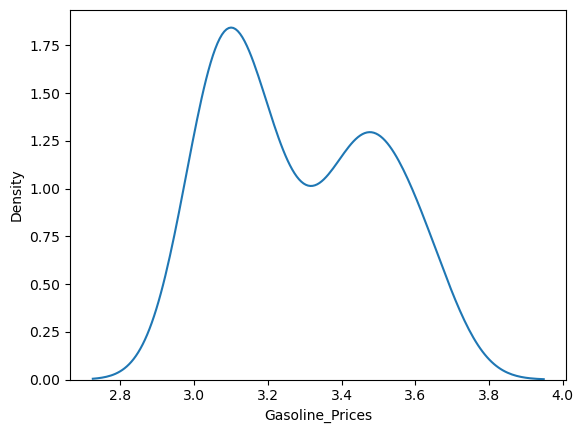

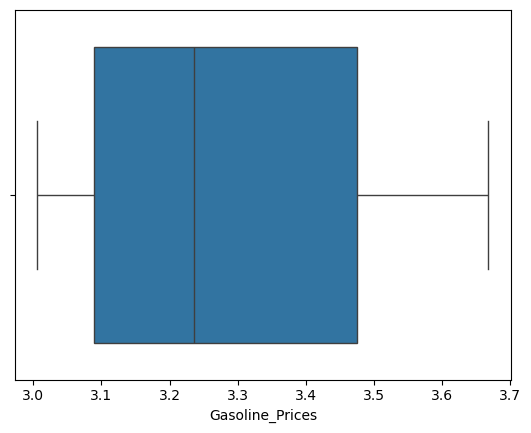

0


In [208]:
# Train
print("Train:")
print(X_train.Gasoline_Prices.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Gasoline_Prices) # kdeplot to see distribution. Slight right-skew
plt.show() 
sns.boxplot(x = X_train.Gasoline_Prices) # boxplot to see distribution.
plt.show() # outliers are periods of high gas prices, not data errors
print(X_train.Gasoline_Prices.isna().sum()) # Check Missing values
# Keep as is for interpretability

# Test
print("Test:")
print(X_test.Gasoline_Prices.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Gasoline_Prices) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test.Gasoline_Prices) # boxplot to see distribution. 
plt.show()
print(X_test.Gasoline_Prices.isna().sum()) # Check Missing values
# Leave as is as done for train for interpretability

## Gasoline Prices Time-Lag

In [211]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Gasoline_Prices_lag{L}"] = X_train["Gasoline_Prices"].shift(L) # Apply to train
    X_test[f"Gasoline_Prices_lag{L}"] = X_test["Gasoline_Prices"].shift(L) # Apply to test

# Highway Traffic

Train:
min       2833.000000
max       3284.000000
median    3190.000000
mean      3154.048421
std        100.754348
Name: Highway_Traffic, dtype: float64


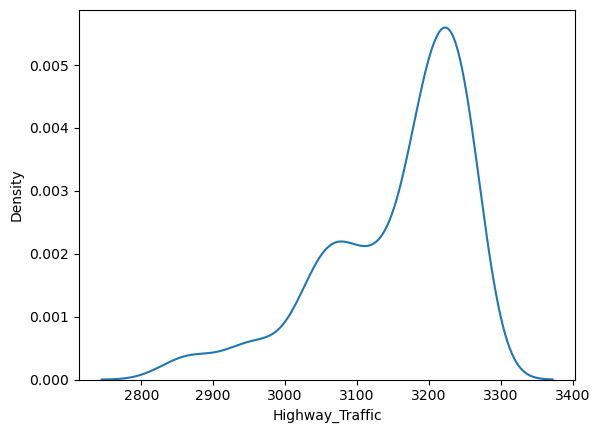

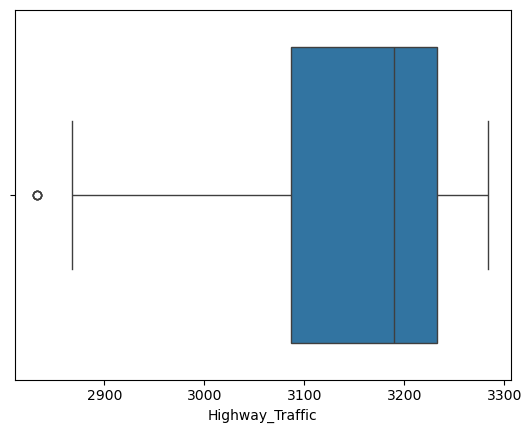

0


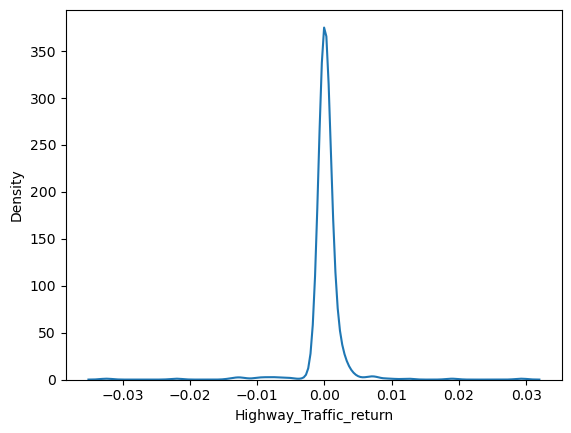

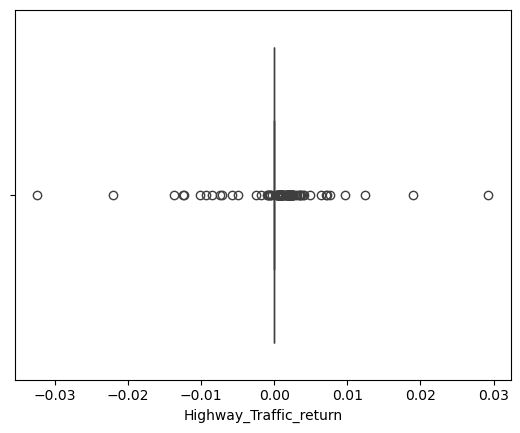

Test:
min       3250.000000
max       3283.000000
median    3266.000000
mean      3267.559322
std         10.342866
Name: Highway_Traffic, dtype: float64


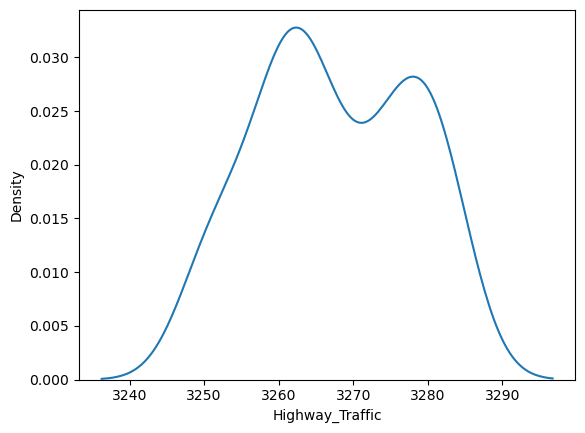

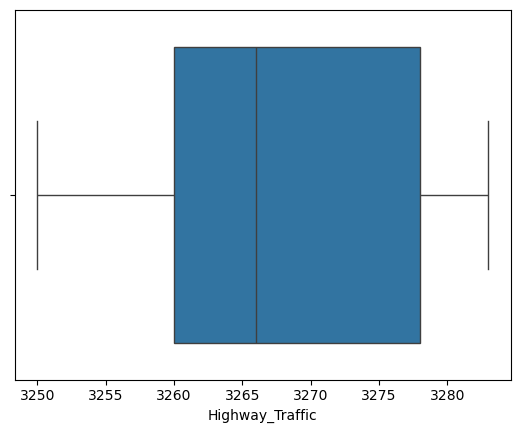

0


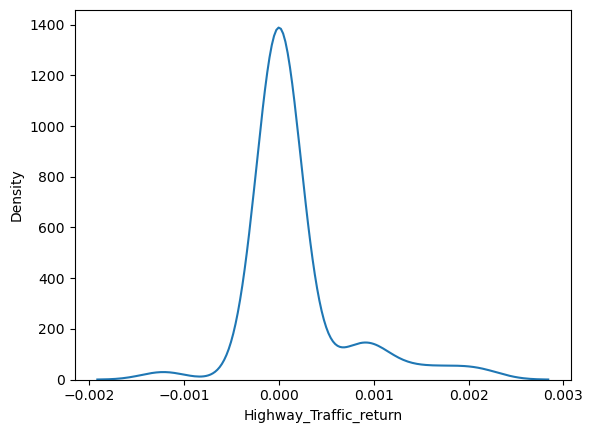

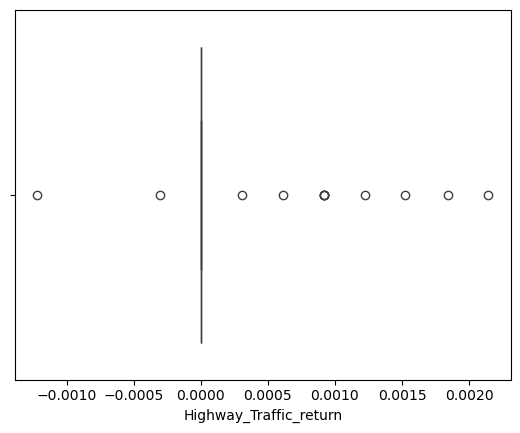

In [214]:
# Train
print("Train:")
print(X_train.Highway_Traffic.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Highway_Traffic) # kdeplot to see distribution. Left-skewed
plt.show() 
sns.boxplot(x = X_train.Highway_Traffic) # boxplot to see distribution. 
plt.show() # outliers are cases of lower traffic, not necessarily errors. It provides important information to capture
print(X_train.Highway_Traffic.isna().sum()) # Check Missing values

X_train["Highway_Traffic_return"] = X_train["Highway_Traffic"].pct_change() # New variable to capture sudden spikes
sns.kdeplot(x = X_train.Highway_Traffic_return) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_train.Highway_Traffic_return) # boxplot to see distribution. 
plt.show()

X_train = X_train.drop(columns=['Highway_Traffic']) # Drop original

# Test
print("Test:")
print(X_test.Highway_Traffic.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Highway_Traffic) # kdeplot to see distribution.
plt.show() 
sns.boxplot(x = X_test.Highway_Traffic) # boxplot to see distribution. 
plt.show()
print(X_test.Highway_Traffic.isna().sum()) # Check Missing values

X_test["Highway_Traffic_return"] = X_test["Highway_Traffic"].pct_change() # Create same new variable for test
sns.kdeplot(x = X_test.Highway_Traffic_return) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_test.Highway_Traffic_return) # boxplot to see distribution. 
plt.show()

X_test = X_test.drop(columns=['Highway_Traffic']) # Drop original

## Highway Traffic Time-Lag

In [216]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Highway_Traffic_return_lag{L}"] = X_train["Highway_Traffic_return"].shift(L) # Apply to train
    X_test[f"Highway_Traffic_return_lag{L}"] = X_test["Highway_Traffic_return"].shift(L) # Apply to test

# Personal Consumption Expenditures

Train:
min       12066.700000
max       19446.500000
median    14248.600000
mean      14891.307368
std        2194.917038
Name: PCE, dtype: float64


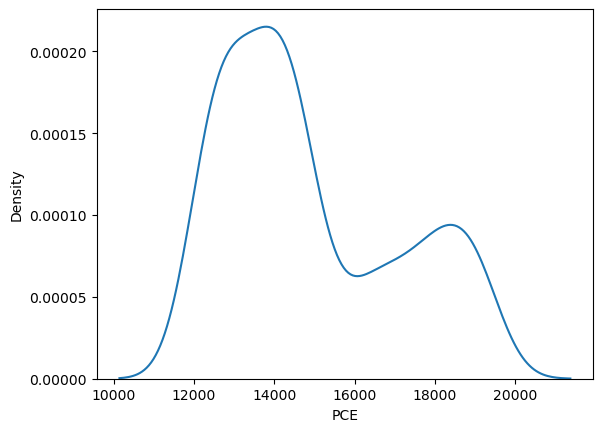

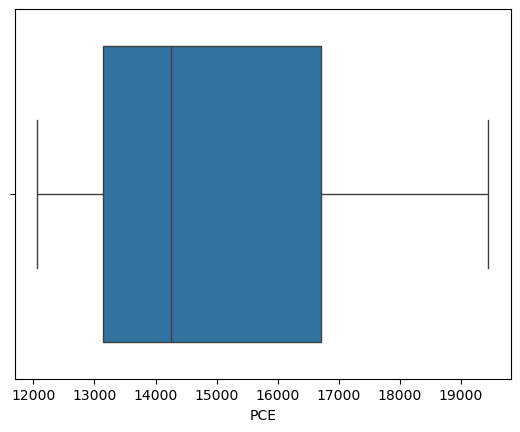

0


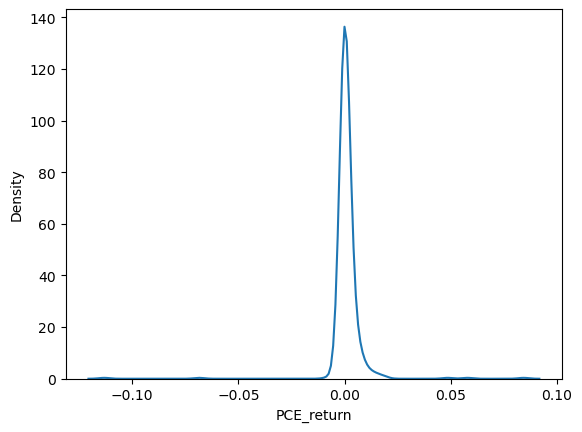

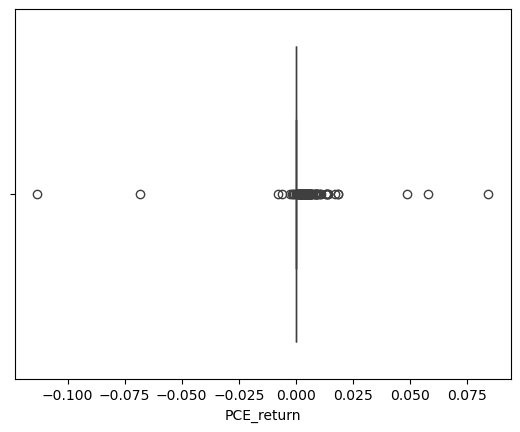

Test:
min       19446.500000
max       20683.000000
median    20147.600000
mean      20086.388136
std         371.297744
Name: PCE, dtype: float64


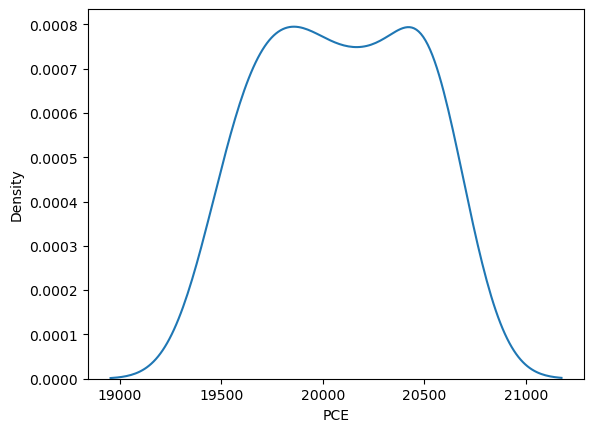

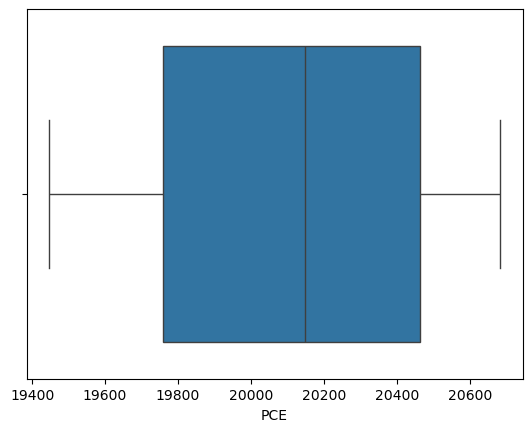

0


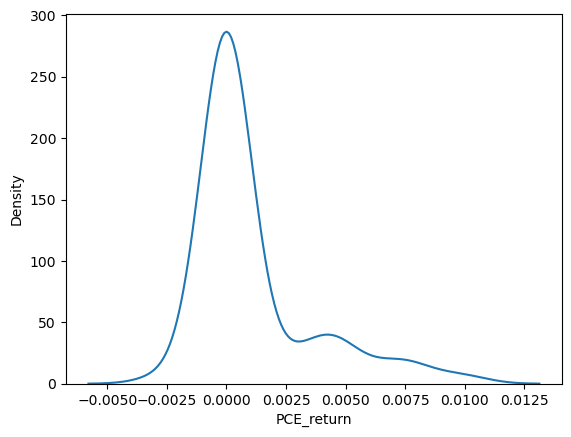

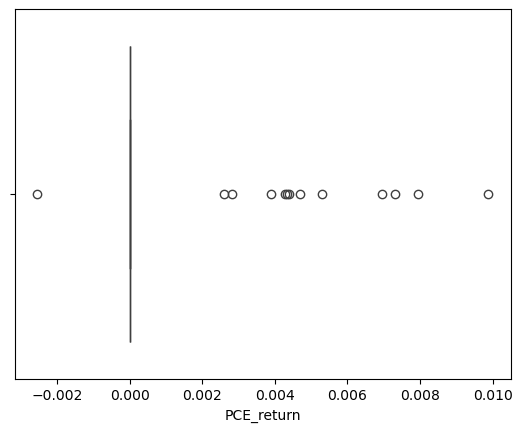

In [220]:
# Train
print("Train:")
print(X_train.PCE.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.PCE) # kdeplot to see distribution. slight right-skew
plt.show() 
sns.boxplot(x = X_train.PCE) # boxplot to see distribution. 
plt.show() # outliers are cases of higher PCE, not data errors, and provide valuable information to capture
print(X_train.PCE.isna().sum()) # Check Missing values

X_train["PCE_return"] = X_train["PCE"].pct_change() # New variable to capture sudden spikes
sns.kdeplot(x = X_train.PCE_return) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_train.PCE_return) # boxplot to see distribution. 
plt.show()

X_train = X_train.drop(columns=['PCE']) # Drop original

# Test
print("Test:")
print(X_test.PCE.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.PCE) # kdeplot to see distribution.
plt.show() 
sns.boxplot(x = X_test.PCE) # boxplot to see distribution. 
plt.show()
print(X_test.PCE.isna().sum()) # Check Missing values

X_test["PCE_return"] = X_test["PCE"].pct_change() # Create same new variable for test
sns.kdeplot(x = X_test.PCE_return) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_test.PCE_return) # boxplot to see distribution. 
plt.show()

X_test = X_test.drop(columns=['PCE']) # Drop original

## PCE Time-Lag

In [222]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"PCE_return_lag{L}"] = X_train["PCE_return"].shift(L) # Apply to train
    X_test[f"PCE_return_lag{L}"] = X_test["PCE_return"].shift(L) # Apply to test

# Financial Stress Index (STLFSI4)

Train:
min      -0.903100
max       5.631900
median   -0.275100
mean     -0.184917
std       0.625969
Name: Financial_Stress_Index, dtype: float64


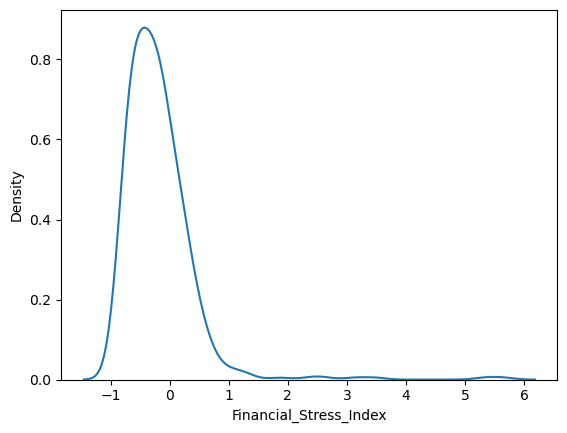

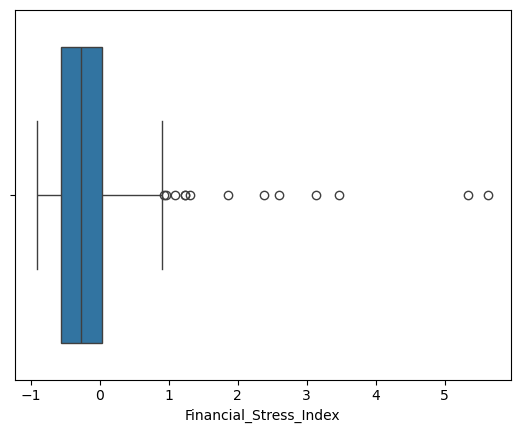

0
Test:
min      -0.976100
max      -0.165600
median   -0.661200
mean     -0.663095
std       0.207306
Name: Financial_Stress_Index, dtype: float64


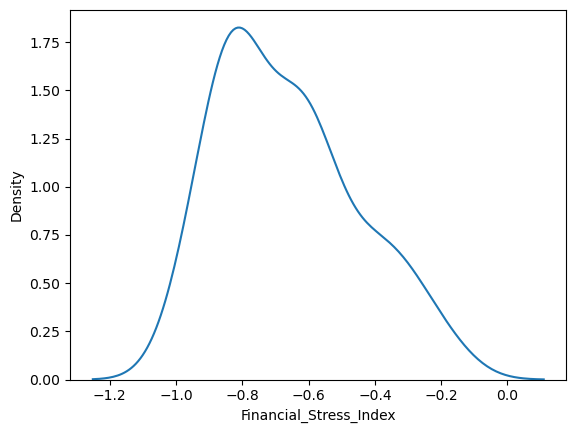

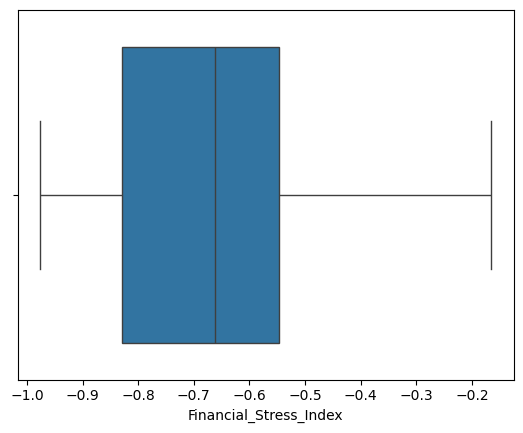

0


In [226]:
# Train
print("Train:")
print(X_train.Financial_Stress_Index.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Financial_Stress_Index) # kdeplot to see distribution. Strong right-skew but not surprising.
plt.show() 
sns.boxplot(x = X_train.Financial_Stress_Index) # boxplot to see distribution.
plt.show() # data represents actual market stress. Outliers are the Covid market crash, oil price wars, etc. All signals, not noise.
print(X_train.Financial_Stress_Index.isna().sum()) # Check Missing values
# Keep as is for interpretability

# Test
print("Test:")
print(X_test.Financial_Stress_Index.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Financial_Stress_Index) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test.Financial_Stress_Index) # boxplot to see distribution. 
plt.show()
print(X_test.Financial_Stress_Index.isna().sum()) # Check Missing values
# Leave as is as done for train for interpretability

## Financial Stress Index Time-Lag

In [229]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Financial_Stress_Index_lag{L}"] = X_train["Financial_Stress_Index"].shift(L) # Apply to train
    X_test[f"Financial_Stress_Index_lag{L}"] = X_test["Financial_Stress_Index"].shift(L) # Apply to test

# Geopolitical Risk Index

Train:
min        46.818570
max       414.934300
median     94.980000
mean      103.337287
std        39.540418
Name: GeoPolitical_Risk_Index, dtype: float64


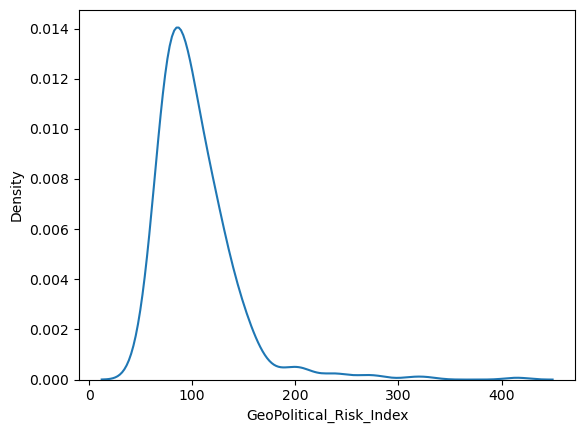

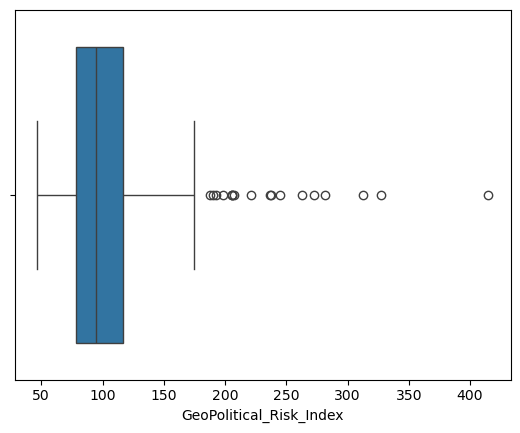

0
Test:
min        73.102860
max       203.450000
median    130.410000
mean      131.104458
std        26.455269
Name: GeoPolitical_Risk_Index, dtype: float64


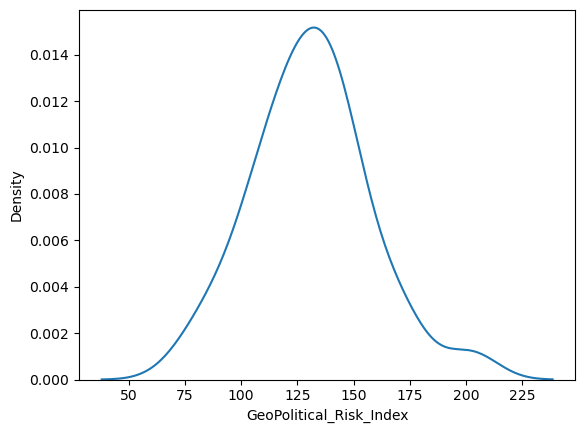

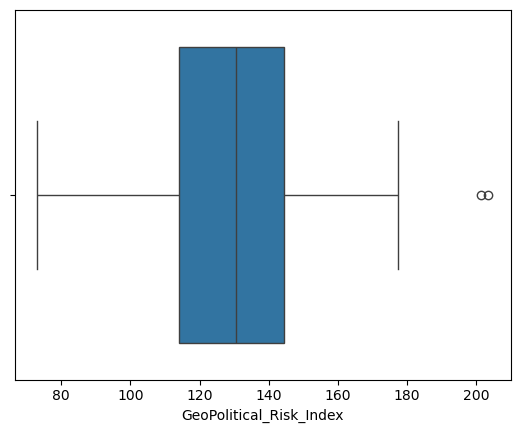

0


In [232]:
# Train
print("Train:")
print(X_train.GeoPolitical_Risk_Index.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.GeoPolitical_Risk_Index) # kdeplot to see distribution. Strong right-skew but not surprising.
plt.show() 
sns.boxplot(x = X_train.GeoPolitical_Risk_Index) # boxplot to see distribution.
plt.show() # outliers would be real-life crisis events causing spikes. This is important to capture. 
print(X_train.GeoPolitical_Risk_Index.isna().sum()) # Check Missing values
# Keep as is for interpretability

# Test
print("Test:")
print(X_test.GeoPolitical_Risk_Index.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.GeoPolitical_Risk_Index) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test.GeoPolitical_Risk_Index) # boxplot to see distribution. 
plt.show()
print(X_test.GeoPolitical_Risk_Index.isna().sum()) # Check Missing values
# Leave as is as done for train for interpretability

## Geopolitical Risk Index Time-Lag

In [235]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"GeoPolitical_Risk_Index_lag{L}"] = X_train["GeoPolitical_Risk_Index"].shift(L) # Apply to train
    X_test[f"GeoPolitical_Risk_Index_lag{L}"] = X_test["GeoPolitical_Risk_Index"].shift(L) # Apply to test

# Average Vehicle Miles Traveled (VMT) per Capita

Train:
min       167617.000000
max       293308.000000
median    268343.000000
mean      263614.172632
std        20908.472388
Name: Average_VMT, dtype: float64


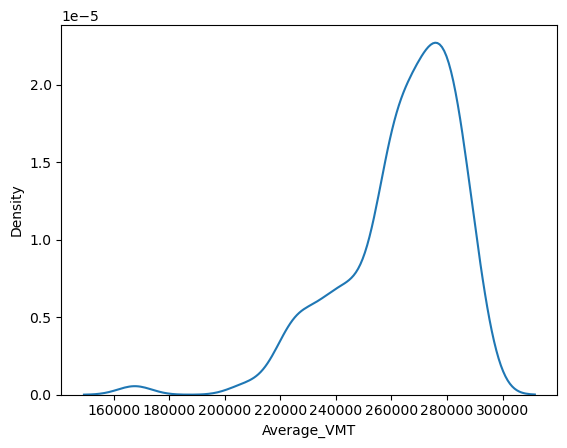

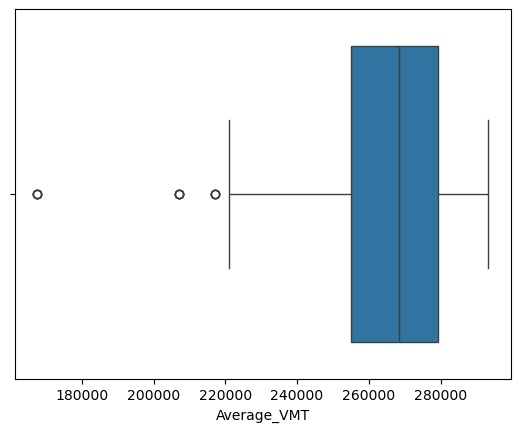

0
Test:
min       237493.000000
max       292503.000000
median    274585.000000
mean      272003.864407
std        17044.066617
Name: Average_VMT, dtype: float64


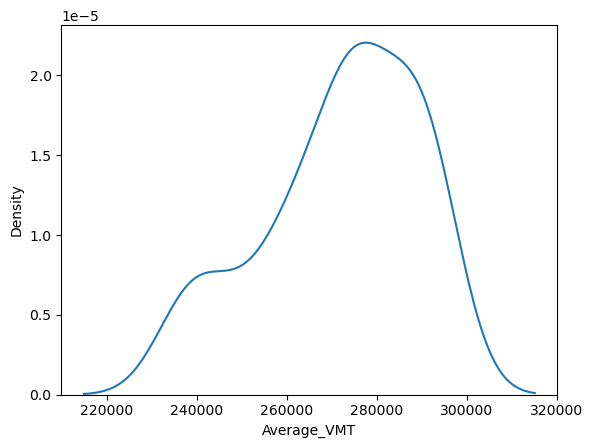

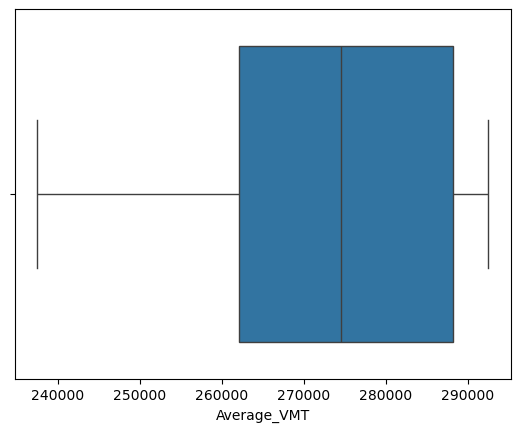

0


In [238]:
# Train
print("Train:")
print(X_train.Average_VMT.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.Average_VMT) # kdeplot to see distribution. Left-skew, but not surprising.
plt.show() 
sns.boxplot(x = X_train.Average_VMT) # boxplot to see distribution.
plt.show() # Data shows the true size of the driving economy. Outliers are periods of low vehicle usage caused by crises (Covid), not errors. 
print(X_train.Average_VMT.isna().sum()) # Check Missing values
# Keep as is for interpretability

# Test
print("Test:")
print(X_test.Average_VMT.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.Average_VMT) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test.Average_VMT) # boxplot to see distribution. 
plt.show()
print(X_test.Average_VMT.isna().sum()) # Check Missing values
# Leave as is as done for train for interpretability

## Average VMT Time-Lag

In [241]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Average_VMT_lag{L}"] = X_train["Average_VMT"].shift(L) # Apply to train
    X_test[f"Average_VMT_lag{L}"] = X_test["Average_VMT"].shift(L) # Apply to test

# Gasoline Stocks

Train:
min       13889.000000
max       31072.000000
median    23175.000000
mean      22468.054737
std        3930.924153
Name: Gasoline_Stocks (thousands), dtype: float64


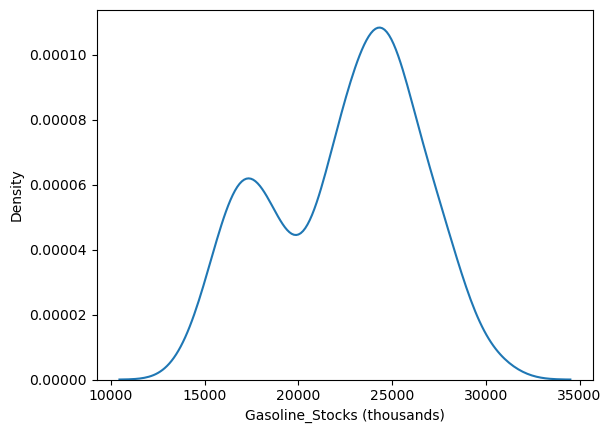

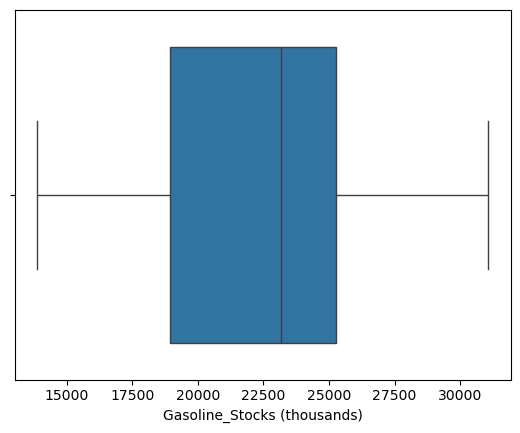

0
Test:
min       13057.000000
max       18346.000000
median    15779.000000
mean      15792.525424
std        1387.556564
Name: Gasoline_Stocks (thousands), dtype: float64


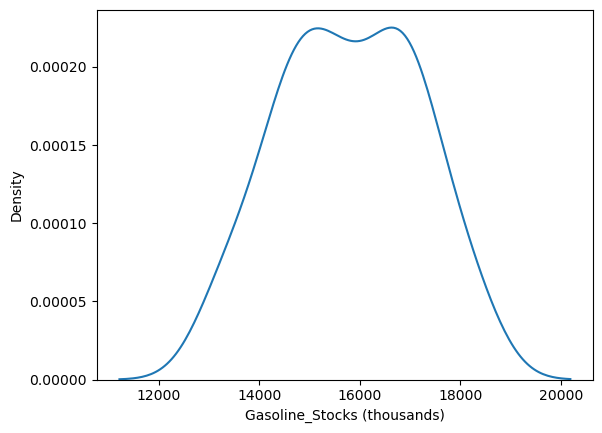

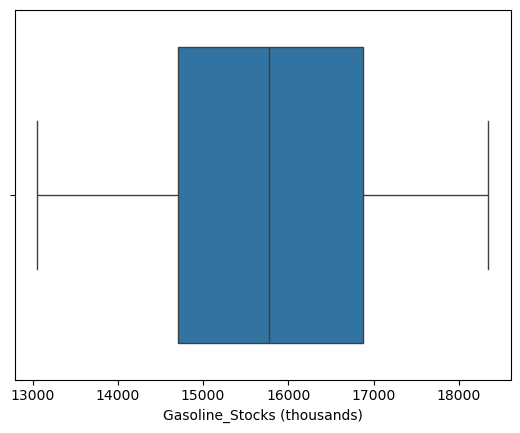

0


In [244]:
# Train
print("Train:")
print(X_train['Gasoline_Stocks (thousands)'].agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train['Gasoline_Stocks (thousands)']) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_train['Gasoline_Stocks (thousands)']) # boxplot to see distribution. 
plt.show() 
print(X_train['Gasoline_Stocks (thousands)'].isna().sum()) # Check Missing values
# Keep as is (seasonal pattern retained)

# Test
print("Test:")
print(X_test['Gasoline_Stocks (thousands)'].agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test['Gasoline_Stocks (thousands)']) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test['Gasoline_Stocks (thousands)']) # boxplot to see distribution. 
plt.show()
print(X_test['Gasoline_Stocks (thousands)'].isna().sum()) # Check Missing values
# Leave as is as done for train

## Gasoline Stocks Time-Lag

In [247]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5]

for L in lags:
    X_train[f"Gasoline_Stocks_(thousands)_lag{L}"] = X_train["Gasoline_Stocks (thousands)"].shift(L) # Apply to train
    X_test[f"Gasoline_Stocks_(thousands)_lag{L}"] = X_test["Gasoline_Stocks (thousands)"].shift(L) # Apply to test

# Crude Oil Imports

Train:
min       4599.000000
max       9372.000000
median    6978.000000
mean      6953.751579
std        914.567919
Name: Crude_Oil_Imports (thousands), dtype: float64


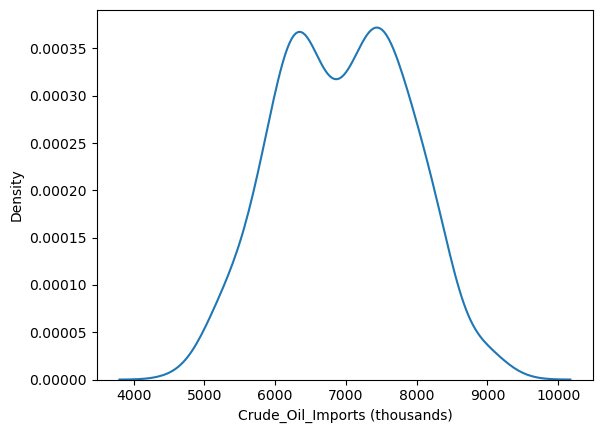

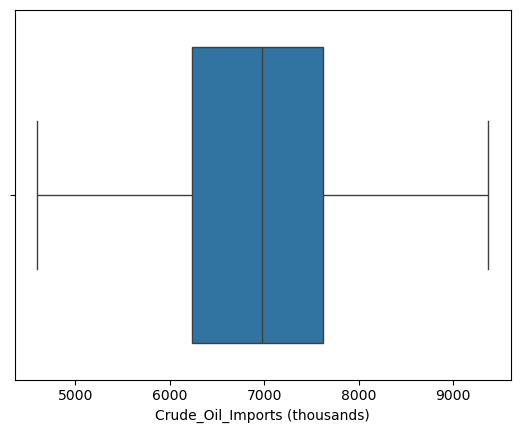

0
Test:
min       5385.000000
max       8304.000000
median    6497.000000
mean      6503.237288
std        519.892673
Name: Crude_Oil_Imports (thousands), dtype: float64


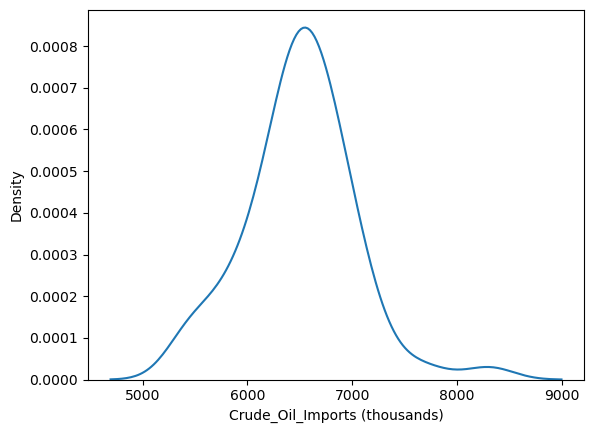

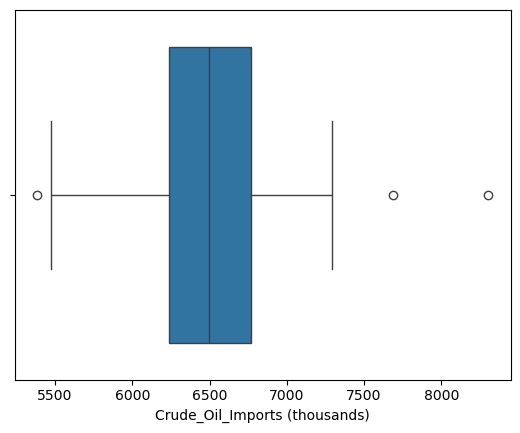

0


In [250]:
# Train
print("Train:")
print(X_train['Crude_Oil_Imports (thousands)'].agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train['Crude_Oil_Imports (thousands)']) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_train['Crude_Oil_Imports (thousands)']) # boxplot to see distribution. 
plt.show() 
print(X_train['Crude_Oil_Imports (thousands)'].isna().sum()) # Check Missing values
# Keep as is 

# Test
print("Test:")
print(X_test['Crude_Oil_Imports (thousands)'].agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test['Crude_Oil_Imports (thousands)']) # kdeplot to see distribution. 
plt.show()
sns.boxplot(x = X_test['Crude_Oil_Imports (thousands)']) # boxplot to see distribution. 
plt.show()
print(X_test['Crude_Oil_Imports (thousands)'].isna().sum()) # Check Missing values
# Leave as is as done for train

## Crude Oil Imports Time-Lag

In [253]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5, 6, 7]

for L in lags:
    X_train[f"Crude_Oil_Imports_(thousands)_lag{L}"] = X_train["Crude_Oil_Imports (thousands)"].shift(L) # Apply to train
    X_test[f"Crude_Oil_Imports_(thousands)_lag{L}"] = X_test["Crude_Oil_Imports (thousands)"].shift(L) # Apply to test

# US GDP

Train:
min       18063.530000
max       28708.160000
median    21397.940000
mean      22067.376000
std        3185.464623
Name: US_GDP, dtype: float64


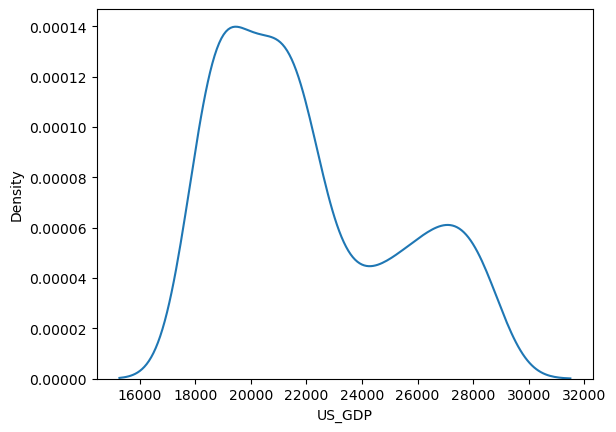

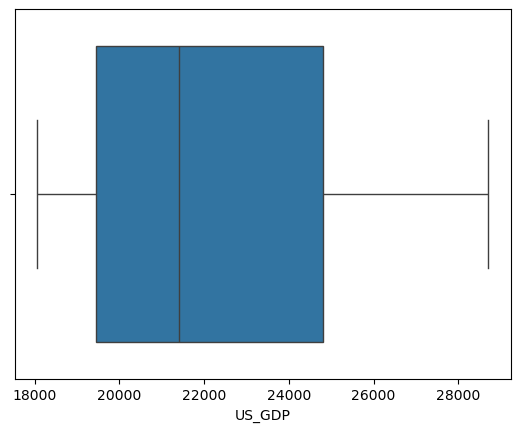

0


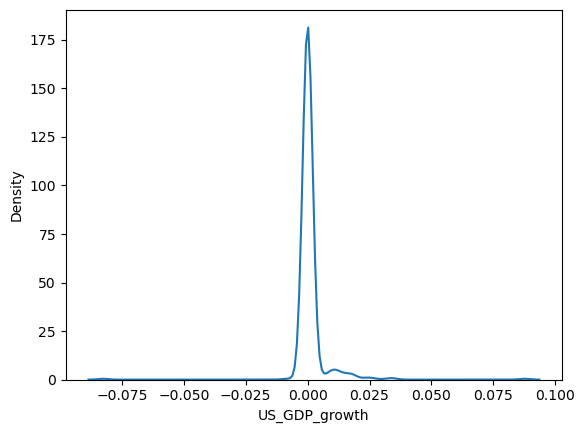

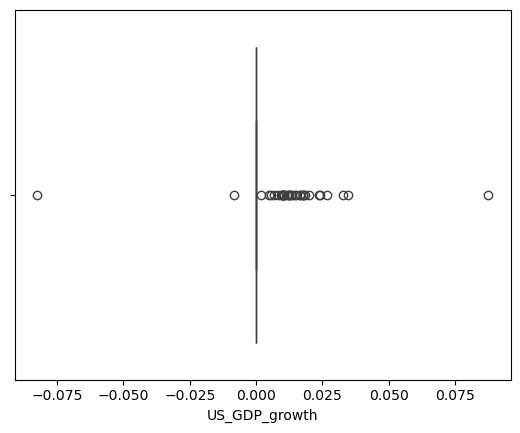

Test:
min       28708.160000
max       30042.110000
median    29511.660000
mean      29499.339661
std         446.028871
Name: US_GDP, dtype: float64


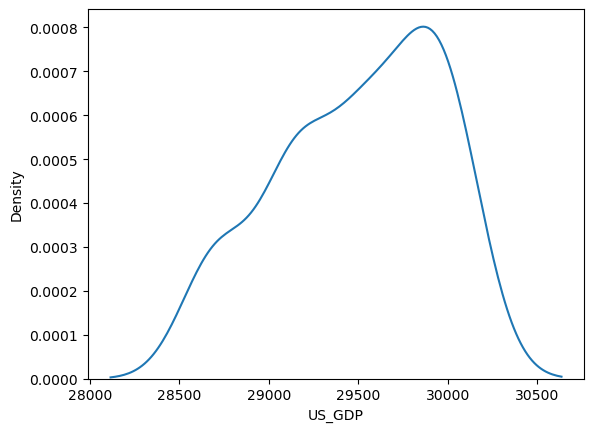

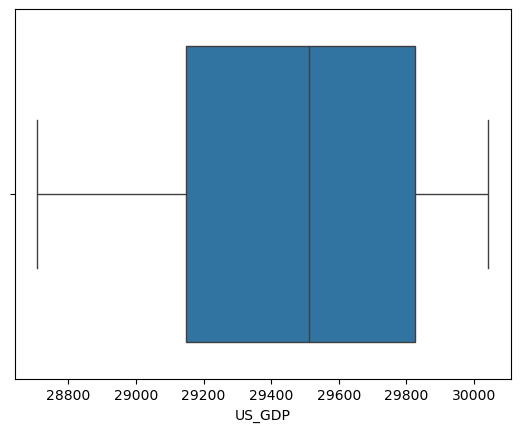

0


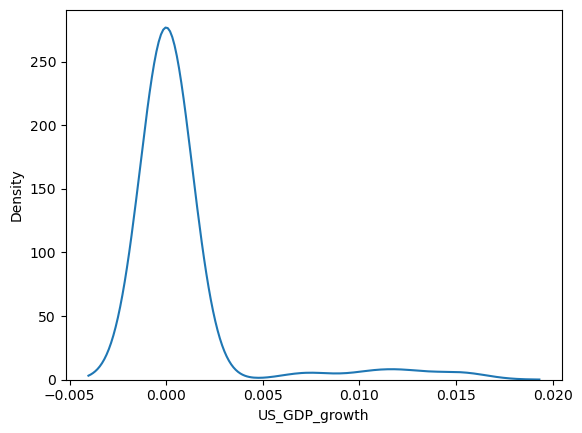

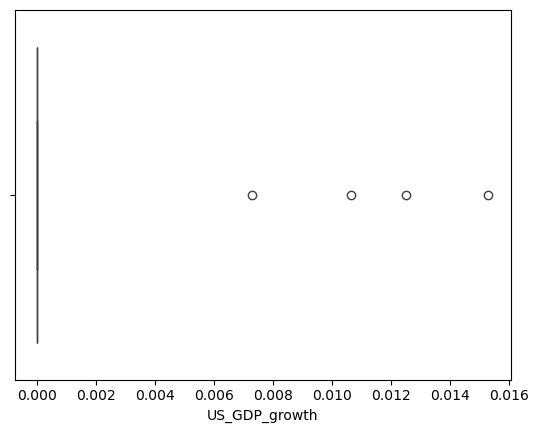

In [256]:
# Train
print("Train:")
print(X_train.US_GDP.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_train.US_GDP) # kdeplot to see distribution.
plt.show() 
sns.boxplot(x = X_train.US_GDP) # boxplot to see distribution. 
plt.show() 
print(X_train.US_GDP.isna().sum()) # Check Missing values

X_train["US_GDP_growth"] = X_train["US_GDP"].pct_change() # New variable to capture GDP growth
sns.kdeplot(x = X_train.US_GDP_growth) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_train.US_GDP_growth) # boxplot to see distribution. 
plt.show()

X_train = X_train.drop(columns=['US_GDP']) # Drop original

# Test
print("Test:")
print(X_test.US_GDP.agg(['min','max','median','mean','std'])) # descriptive stats
sns.kdeplot(x = X_test.US_GDP) # kdeplot to see distribution.
plt.show() 
sns.boxplot(x = X_test.US_GDP) # boxplot to see distribution. 
plt.show()
print(X_test.US_GDP.isna().sum()) # Check Missing values

X_test["US_GDP_growth"] = X_test["US_GDP"].pct_change() # Create same new variable for test
sns.kdeplot(x = X_test.US_GDP_growth) # kdeplot to see distribution. 
plt.show() 
sns.boxplot(x = X_test.US_GDP_growth) # boxplot to see distribution. 
plt.show()

X_test = X_test.drop(columns=['US_GDP']) # Drop original

## US GDP Time-Lag

In [258]:
# Create time-lags (3–5 weeks)
lags = [3, 4, 5, 6, 7]


#add a year lag, 51, 52, 53 
# add the xgboost code to AI and set the obejctive so that it can change the parameters to better achieve this goal
#if this doesnt work, this has to be what you discovered. 
#Hint: autocorrelation and see what it is. See if this gives me ahint as to what might be a good predictor. 

for L in lags:
    X_train[f"US_GDP_growth_lag{L}"] = X_train["US_GDP_growth"].shift(L) # Apply to train
    X_test[f"US_GDP_growth_lag{L}"] = X_test["US_GDP_growth"].shift(L) # Apply to test

# Target Variable: High Demand (for Gasoline)

In [276]:
print(y_train.value_counts()) # Checking the occurrences of high demand for train
print(y_test.value_counts()) # Checking the occurrences of high demand for test

High_Demand
1    257
0    218
Name: count, dtype: int64
High_Demand
0    42
1    17
Name: count, dtype: int64


# Getting Rid of Remaining NA's
For each col that we created a new pct_change col, an additional row of NA was introduced to the dataset. In addition, every time we time-lagged the predictors, new NA rows were introduced. The following code ensures that alignment is not altered while getting rid of the new NA rows.

In [279]:
# Clean train
train_mask = X_train.notna().all(axis=1) # Identifies all rows that are not NA
X_train = X_train.loc[train_mask].reset_index(drop=True) # Ensures these rows are in X_train
y_train = y_train.loc[train_mask].reset_index(drop=True) # Ensures these rows are in y_train

# Clean test
test_mask = X_test.notna().all(axis=1) # Identifies all rows that are not NA
X_test = X_test.loc[test_mask].reset_index(drop=True) # Ensures these rows are in X_test
y_test = y_test.loc[test_mask].reset_index(drop=True) # Ensures these rows are in y_test

y_test.shape

(51,)

# XGBoost Model

In [282]:
# CLASS DISTRIBUTION IN TRAIN AND TEST
# This helps us see how imbalanced the High_Demand variable is.

print("y_train class distribution (0 = low demand, 1 = high demand):")
print(y_train.value_counts(normalize=True))
print("\nY_test class distribution (0 = low demand, 1 = high demand):")
print(y_test.value_counts(normalize=True))

y_train class distribution (0 = low demand, 1 = high demand):
High_Demand
1    0.550321
0    0.449679
Name: proportion, dtype: float64

Y_test class distribution (0 = low demand, 1 = high demand):
High_Demand
0    0.705882
1    0.294118
Name: proportion, dtype: float64


**Reflection**


In train:
~57.5% = class 0 (low demand)
~42.5% = class 1 (high demand)

In Test:
~69.7% = class 0 (low demand)
~30.3% = class 1 (high demand)

High demand (class 1) is not as rare as it was for the 90th quantile.


In [285]:
# DROP NON-NUMERIC COLUMNS FOR XGBOOST ---
# XGBoost can only handle features that are: int, float, bool, or category
# We create numeric-only versions of X_train and X_test.

non_numeric_cols = X_train.select_dtypes(exclude=['number', 'bool']).columns
print("\nColumns that will be dropped for XGBoost:", list(non_numeric_cols))

X_train_xgb = X_train.drop(columns=non_numeric_cols)
X_test_xgb = X_test.drop(columns=non_numeric_cols)


Columns that will be dropped for XGBoost: ['Week']



--- Model Training will be Cost-Aware ---
Cost Ratio (FN_cost / FP_cost): 0.2

--- Starting XGBoost Hyperparameter Tuning ---
Fitting 3 folds for each of 64 candidates, totalling 192 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:11:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:11:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:11:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [23:11:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i


--- XGBoost Tuning Complete ---
Best hyperparameters found:
{'colsample_bytree': 0.6, 'gamma': 0.5, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.6}

--- XGBoost Performance on Test Set (Default 0.5 Threshold) ---
Accuracy: 0.73

--- Classification Report (Default 0.5 Threshold) ---
              precision    recall  f1-score   support

           0       0.73      0.97      0.83        36
           1       0.67      0.13      0.22        15

    accuracy                           0.73        51
   macro avg       0.70      0.55      0.53        51
weighted avg       0.71      0.73      0.65        51


*** How to Read the Classification Report: ***
- Precision: % of predicted 1’s that were actually correct.
- Recall: % of actual 1’s correctly identified.
- F1-Score: Balance between precision & recall.
- Support: Count of true samples per class.
- Accuracy: % of total predictions that were correct.

--- Cost Matrix Used for Training ---
True Negative (TN)

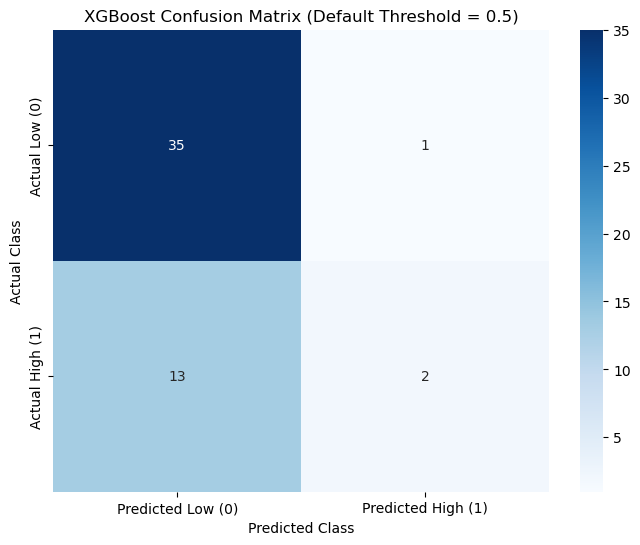

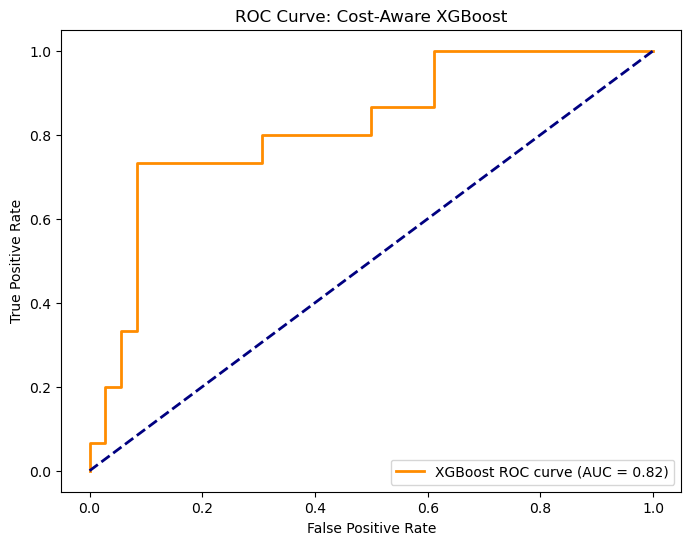


--- Optimal Threshold Selection ---
Optimal Threshold: 0.29
Minimum Total Cost: 8
Mean Cost per Observation: 0.157


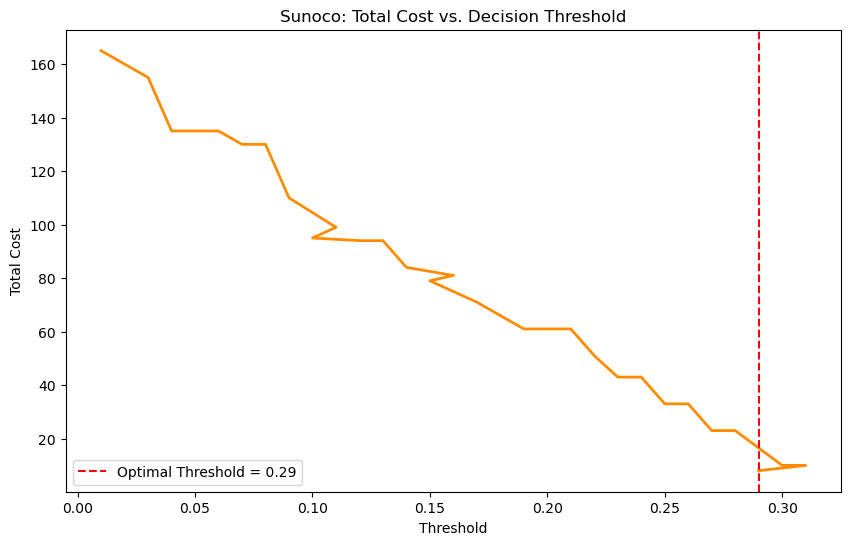


--- XGBoost Performance at Optimal Threshold (0.29) ---
              precision    recall  f1-score   support

           0       0.89      0.92      0.90        36
           1       0.79      0.73      0.76        15

    accuracy                           0.86        51
   macro avg       0.84      0.82      0.83        51
weighted avg       0.86      0.86      0.86        51



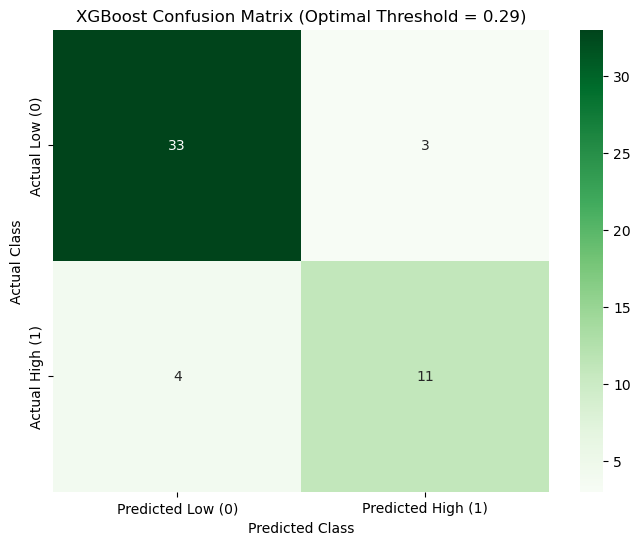

<Figure size 1000x600 with 0 Axes>

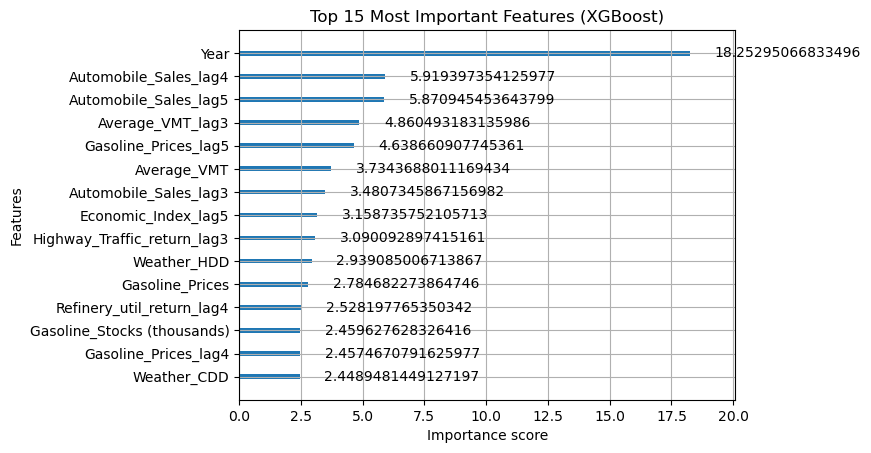

In [287]:
# ==========================
# COST-AWARE XGBOOST MODEL
# ==========================

# --- STEP 6: DEFINE COST MATRIX (Sunoco S&T Priorities) ---
# According to Karina, the goal is to minimize False Positives.
# So, we assign a *high cost* to FP and lower (or zero) cost to FN.

FP_cost = 5    # Predicting high demand when it was actually low (most expensive mistake)
FN_cost = 1    # Predicting low demand when actual was high
TP_cost = -1    # Reward for correctly predicting high demand
TN_cost = 0    # Neutral outcome for correctly predicting low demand

# Cost ratio = FN / FP → used to balance class weights
cost_ratio = FN_cost / FP_cost  # Here, 0 / 2 = 0

# Define class weights for potential neural nets (not used here but for reference)
class_weights_sunoco = {0: 1/9, 1: 1}

print(f"\n--- Model Training will be Cost-Aware ---")
print(f"Cost Ratio (FN_cost / FP_cost): {cost_ratio}")
# print(f"XGBoost will use `scale_pos_weight` = {cost_ratio}")
# print(f"Keras NN would use `class_weight` = {class_weights_sunoco}")


# --- STEP 7: XGBOOST MODELING & GRID SEARCH (COST-AWARE) ---
# We’ll tune key hyperparameters to balance bias-variance and include the cost ratio.
# neg = (y_train == 0).sum()
# pos = (y_train == 1).sum()
# base_spw = neg / pos    # Quite imbalanced 

param_grid_xgb = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'gamma': [0, 0.5],
    'max_depth': [3, 5],
    "subsample": [0.6, 0.8],
    "colsample_bytree": [0.6, 0.8]
}
 

xgbc = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='aucpr', #this model works better than logloss
    random_state=42,
    scale_pos_weight= 0.40   # < 1 to minimize FP
)

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
tscv = TimeSeriesSplit(n_splits=3)
grid_search_xgb = GridSearchCV(xgbc, param_grid_xgb, cv=tscv, scoring="roc_auc", n_jobs=-1, verbose=1)

print("\n--- Starting XGBoost Hyperparameter Tuning ---")
grid_search_xgb.fit(X_train_xgb, y_train)
print("\n--- XGBoost Tuning Complete ---")
print("Best hyperparameters found:")
print(grid_search_xgb.best_params_)

best_model_xgb = grid_search_xgb.best_estimator_


# --- STEP 8: EVALUATE COST-AWARE MODEL (DEFAULT 0.5 THRESHOLD) ---
predictions_default_xgb = best_model_xgb.predict(X_test_xgb)
accuracy_default_xgb = accuracy_score(y_test, predictions_default_xgb)

print("\n--- XGBoost Performance on Test Set (Default 0.5 Threshold) ---")
print(f"Accuracy: {accuracy_default_xgb:.2f}")
print("\n--- Classification Report (Default 0.5 Threshold) ---")
print(classification_report(y_test, predictions_default_xgb))

print("\n*** How to Read the Classification Report: ***")
print("- Precision: % of predicted 1’s that were actually correct.")
print("- Recall: % of actual 1’s correctly identified.")
print("- F1-Score: Balance between precision & recall.")
print("- Support: Count of true samples per class.")
print("- Accuracy: % of total predictions that were correct.")

# --- Display Cost Matrix ---
print("\n--- Cost Matrix Used for Training ---")
print(f"True Negative (TN): {TN_cost}")
print(f"False Positive (FP): {FP_cost}")
print(f"False Negative (FN): {FN_cost}")
print(f"True Positive (TP): {TP_cost}")

# --- Confusion Matrix (Default Threshold) ---
cm_default_xgb = confusion_matrix(y_test, predictions_default_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_default_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low (0)', 'Predicted High (1)'],
            yticklabels=['Actual Low (0)', 'Actual High (1)'])
plt.title('XGBoost Confusion Matrix (Default Threshold = 0.5)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()


# --- ROC Curve & AUC Score ---
y_pred_proba_xgb = best_model_xgb.predict_proba(X_test_xgb)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2,
         label=f'XGBoost ROC curve (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve: Cost-Aware XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()


# --- STEP 9: FIND OPTIMAL THRESHOLD BASED ON SUNOCO COST MATRIX ---
thresholds = np.arange(0.01, 1.0, 0.01)
total_costs_xgb = []
num_obs = len(y_test)

for thresh in thresholds:
    preds_thresh = (y_pred_proba_xgb >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_thresh).ravel()
    cost = (tn * TN_cost) + (fp * FP_cost) + (fn * FN_cost) + (tp * TP_cost)
    total_costs_xgb.append({'thr':thresh, 'tp':tp, 'fp':fp, 'fn':fn, 'tn':tn, 'cost':cost})

res = pd.DataFrame(total_costs_xgb) # Convert to dataframe

TP_MIN  = 10 # require at least this many true positives on test

res = res[res['tp'] >= TP_MIN].sort_values('cost', ascending=True) # Enforce catching some TP (there was previously 0 for TP)
best_thr = 0.5 if res.empty else float(res.iloc[0]['thr']) # Identify threshold that gives lowest cost. If no threshold satisfies the TP_MIN condition, default to 0.5
min_cost = res.cost.min()
min_cost_per_obs = min_cost / num_obs

print(f"\n--- Optimal Threshold Selection ---")
print(f"Optimal Threshold: {best_thr:.2f}")
print(f"Minimum Total Cost: {min_cost}")
print(f"Mean Cost per Observation: {min_cost_per_obs:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(res['thr'], res['cost'], color='darkorange', lw=2)
plt.axvline(x=best_thr, color='red', linestyle='--',
            label=f'Optimal Threshold = {best_thr:.2f}')
plt.title('Sunoco: Total Cost vs. Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Cost')
plt.legend()
plt.show()


# --- STEP 10: EVALUATE MODEL AT OPTIMAL THRESHOLD ---
predictions_optimal_xgb = (y_pred_proba_xgb >= best_thr).astype(int)

print(f"\n--- XGBoost Performance at Optimal Threshold ({best_thr:.2f}) ---")
print(classification_report(y_test, predictions_optimal_xgb))

cm_opt = confusion_matrix(y_test, predictions_optimal_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Low (0)', 'Predicted High (1)'],
            yticklabels=['Actual Low (0)', 'Actual High (1)'])
plt.title(f'XGBoost Confusion Matrix (Optimal Threshold = {best_thr:.2f})')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()
from xgboost import plot_importance
# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(best_model_xgb, max_num_features=15, importance_type='gain')
plt.title("Top 15 Most Important Features (XGBoost)")
plt.show()